# Análisis Estadístico de Ficheros CIE-10-ES y CODIESP

Este notebook realiza un análisis estadístico detallado de los conjuntos de datos relacionados con CIE-10-ES (diagnósticos, procedimientos y productos químicos) y datos de CODIESP, con el objetivo de comprender la distribución y características de estos datos para su uso en un artículo científico.

## 1. Importar Bibliotecas Necesarias

En esta sección, importaremos todas las bibliotecas necesarias para realizar el análisis estadístico y la visualización de datos.

In [1]:
# Importar bibliotecas para análisis de datos
import pandas as pd
import numpy as np

# Bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuraciones de visualización
plt.style.use('ggplot')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Para guardar archivos Markdown
import os
import json
from IPython.display import display, Markdown

In [2]:
# Instalación de dependencias necesarias
%pip install nbformat


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Cargar y Explorar los Datos CSV

Cargaremos los diferentes archivos CSV y realizaremos una exploración inicial para entender su estructura.

In [3]:
# Definir rutas de los archivos CSV
ruta_base = '/Users/david/own/CIE-10/'
ruta_csv_import = os.path.join(ruta_base, 'csv_import_scripts')
ruta_codiesp = os.path.join(ruta_base, 'bert-classifier/codiesp_csvs')

# Archivos CIE-10-ES
archivo_diagnosticos = os.path.join(ruta_csv_import, 'cie10-es-diagnoses.csv')
archivo_procedimientos = os.path.join(ruta_csv_import, 'cie10-es-procedures.csv')
archivo_quimicos = os.path.join(ruta_csv_import, 'cie10-es-chemicals.csv')

# Archivos CODIESP
archivos_codiesp = {
    'train': os.path.join(ruta_codiesp, 'codiesp_D_source_train.csv'),
    'test': os.path.join(ruta_codiesp, 'codiesp_D_source_test.csv'),
    'validation': os.path.join(ruta_codiesp, 'codiesp_D_source_validation.csv')
}

print("Archivos CIE-10-ES:")
print(f"- Diagnósticos: {archivo_diagnosticos}")
print(f"- Procedimientos: {archivo_procedimientos}")
print(f"- Químicos: {archivo_quimicos}")
print("\nArchivos CODIESP:")
for tipo, ruta in archivos_codiesp.items():
    print(f"- {tipo}: {ruta}")

Archivos CIE-10-ES:
- Diagnósticos: /Users/david/own/CIE-10/csv_import_scripts/cie10-es-diagnoses.csv
- Procedimientos: /Users/david/own/CIE-10/csv_import_scripts/cie10-es-procedures.csv
- Químicos: /Users/david/own/CIE-10/csv_import_scripts/cie10-es-chemicals.csv

Archivos CODIESP:
- train: /Users/david/own/CIE-10/bert-classifier/codiesp_csvs/codiesp_D_source_train.csv
- test: /Users/david/own/CIE-10/bert-classifier/codiesp_csvs/codiesp_D_source_test.csv
- validation: /Users/david/own/CIE-10/bert-classifier/codiesp_csvs/codiesp_D_source_validation.csv


In [4]:
# Cargar los datos de CIE-10-ES
try:
    print("Cargando archivos CIE-10-ES...")
    df_diagnosticos = pd.read_csv(archivo_diagnosticos)
    df_procedimientos = pd.read_csv(archivo_procedimientos)
    df_quimicos = pd.read_csv(archivo_quimicos)

    # Cargar los datos de CODIESP
    dfs_codiesp = {}
    print("Cargando archivos CODIESP...")
    for tipo, ruta in archivos_codiesp.items():
        dfs_codiesp[tipo] = pd.read_csv(ruta)

    print("Todos los archivos cargados correctamente.")
except Exception as e:
    print(f"Error al cargar los archivos: {str(e)}")

Cargando archivos CIE-10-ES...
Cargando archivos CODIESP...
Todos los archivos cargados correctamente.
Cargando archivos CODIESP...
Todos los archivos cargados correctamente.


### 2.1 Exploración de Datos CIE-10-ES Diagnósticos

Dimensiones del dataset de diagnósticos: (101246, 10)

Información del dataset de diagnósticos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101246 entries, 0 to 101245
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   code             101246 non-null  object
 1   description      101246 non-null  object
 2   perinatal        101246 non-null  int64 
 3   pediatric        101246 non-null  int64 
 4   maternity        101246 non-null  int64 
 5   adult            101246 non-null  int64 
 6   poaExempt        101246 non-null  int64 
 7   noPrincipal      101246 non-null  int64 
 8   exclusiveGender  3961 non-null    object
 9   vcdp             101246 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 7.7+ MB


None


Resumen estadístico del dataset de diagnósticos:


,perinatal,pediatric,maternity,adult,poaExempt,noPrincipal,vcdp
count,101246.000000,101246.000000,101246.000000,101246.000000,101246.000000,101246.000000,101246.000000
mean,0.000405,0.001146,0.025058,0.008188,0.371946,0.095411,0.007674
std,0.020119,0.033829,0.156301,0.090117,0.483326,0.293783,0.087267
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Primeras filas del dataset de diagnósticos:


,code,description,perinatal,pediatric,maternity,adult,poaExempt,noPrincipal,exclusiveGender,vcdp
0,A20,Peste,0,0,0,0,0,0,NaN,0
1,A20.0,Peste bubónica,0,0,0,0,0,0,NaN,0
2,A20.1,Peste celulocutánea,0,0,0,0,0,0,NaN,0
3,A20.2,Peste neumónica,0,0,0,0,0,0,NaN,0
4,A20.3,Meningitis por peste,0,0,0,0,0,0,NaN,0



Valores nulos por columna en el dataset de diagnósticos:


code                   0
description            0
perinatal              0
pediatric              0
maternity              0
adult                  0
poaExempt              0
noPrincipal            0
exclusiveGender    97285
vcdp                   0
dtype: int64


Distribución de códigos por primeras letras (categorías principales):


code
A      694
B      611
C     1472
D     1014
E     1208
F     1086
G      880
H     4290
I     1778
J      452
K     1056
L     1064
M     8652
N     1021
O     3182
P      565
Q     1025
R      913
S    40323
T    15101
U        5
V     7592
W     2187
X     1028
Y     2311
Z     1736
Name: count, dtype: int64

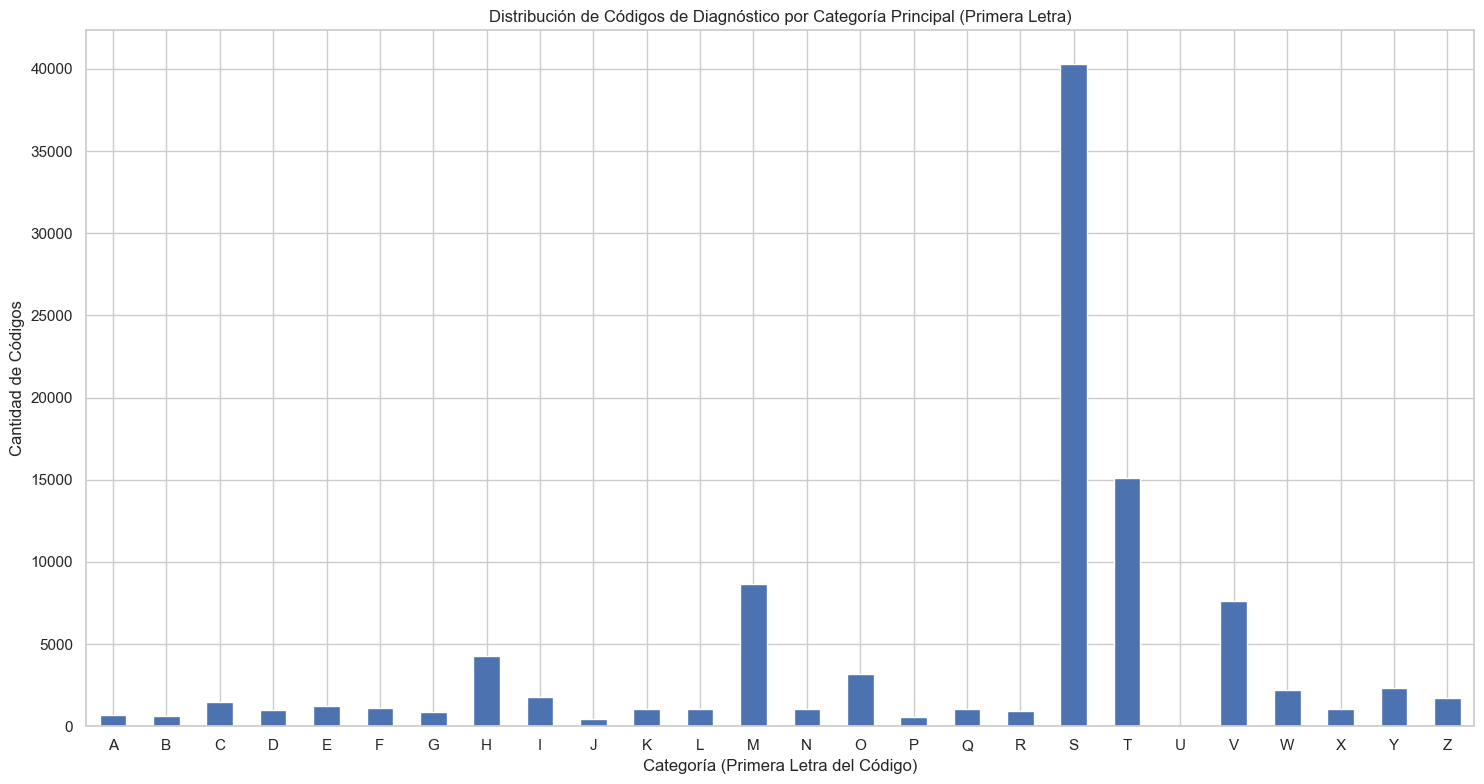

In [5]:
# Exploración inicial de datos de diagnósticos
print(f"Dimensiones del dataset de diagnósticos: {df_diagnosticos.shape}")
print("\nInformación del dataset de diagnósticos:")
display(df_diagnosticos.info())
print("\nResumen estadístico del dataset de diagnósticos:")
display(df_diagnosticos.describe())
print("\nPrimeras filas del dataset de diagnósticos:")
display(df_diagnosticos.head())

# Verificar valores nulos
print("\nValores nulos por columna en el dataset de diagnósticos:")
display(df_diagnosticos.isnull().sum())

# Distribución de las columnas categóricas principales
print("\nDistribución de códigos por primeras letras (categorías principales):")
if 'code' in df_diagnosticos.columns:
    primeras_letras = df_diagnosticos['code'].str[0].value_counts().sort_index()
    display(primeras_letras)

    # Visualización de la distribución
    plt.figure(figsize=(15, 8))
    primeras_letras.plot(kind='bar')
    plt.title('Distribución de Códigos de Diagnóstico por Categoría Principal (Primera Letra)')
    plt.xlabel('Categoría (Primera Letra del Código)')
    plt.ylabel('Cantidad de Códigos')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### 2.2 Exploración de Datos CIE-10-ES Procedimientos

Dimensiones del dataset de procedimientos: (78496, 13)

Información del dataset de procedimientos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78496 entries, 0 to 78495
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code                  78496 non-null  object
 1   class_name            78496 non-null  object
 2   subclass_name         78496 non-null  object
 3   procedure             78496 non-null  object
 4   procedure_definition  76440 non-null  object
 5   localization          78496 non-null  object
 6   approach              78496 non-null  object
 7   device                78496 non-null  object
 8   calification          78496 non-null  object
 9   definition            76440 non-null  object
 10  description           78496 non-null  object
 11  timesSelected         78496 non-null  int64 
 12  gender                4256 non-null   object
dtypes: int64(1), object(12)
memory usage:

None


Resumen estadístico del dataset de procedimientos:


,timesSelected
count,78496.000000
mean,106.224126
std,711.709785
min,4.000000
25%,7.000000
50%,11.000000
75%,30.000000
max,40199.000000



Primeras filas del dataset de procedimientos:


,code,class_name,subclass_name,procedure,procedure_definition,localization,approach,device,calification,definition,description,timesSelected,gender
0,00B00ZX,Médico-Quirúrgica,Sistema Nervioso Central y Nervios Craneales,Escisión,"Eliminar o cortar sin sustituir, una parte de ...",Cerebro,Abierto,Ninguno,Diagnóstico,"Eliminar o cortar sin sustituir, una parte de ...","Escisión de cerebro, diagnóstico, abordaje abi...",1079,NaN
1,00B00ZZ,Médico-Quirúrgica,Sistema Nervioso Central y Nervios Craneales,Escisión,"Eliminar o cortar sin sustituir, una parte de ...",Cerebro,Abierto,Ninguno,Ninguno,"Eliminar o cortar sin sustituir, una parte de ...","Escisión de cerebro, abordaje abierto",3697,NaN
2,00B03ZX,Médico-Quirúrgica,Sistema Nervioso Central y Nervios Craneales,Escisión,"Eliminar o cortar sin sustituir, una parte de ...",Cerebro,Percutáneo,Ninguno,Diagnóstico,"Eliminar o cortar sin sustituir, una parte de ...","Escisión de cerebro, diagnóstico, abordaje per...",534,NaN
3,00B03ZZ,Médico-Quirúrgica,Sistema Nervioso Central y Nervios Craneales,Escisión,"Eliminar o cortar sin sustituir, una parte de ...",Cerebro,Percutáneo,Ninguno,Ninguno,"Eliminar o cortar sin sustituir, una parte de ...","Escisión de cerebro, abordaje percutáneo",250,NaN
4,00B04ZX,Médico-Quirúrgica,Sistema Nervioso Central y Nervios Craneales,Escisión,"Eliminar o cortar sin sustituir, una parte de ...",Cerebro,Endoscópico Percutáneo,Ninguno,Diagnóstico,"Eliminar o cortar sin sustituir, una parte de ...","Escisión de cerebro, diagnóstico, abordaje end...",199,NaN



Valores nulos por columna en el dataset de procedimientos:


code                        0
class_name                  0
subclass_name               0
procedure                   0
procedure_definition     2056
localization                0
approach                    0
device                      0
calification                0
definition               2056
description                 0
timesSelected               0
gender                  74240
dtype: int64


Distribución de procedimientos por clase:


class_name
Médico-Quirúrgica                                   68024
Imagen                                               2978
Radioterapia                                         2056
Rehabilitación Física y Audiología Diagnóstica       1380
Administración                                       1257
Colocación                                            861
Medicina Nuclear                                      463
Medición y Monitorización                             422
Obstetricia                                           304
Nueva Tecnología                                      297
Osteopatía                                            100
Quiropráctica                                          90
Otros Procedimientos                                   78
Tratamiento de Abuso de Sustancias                     59
Asistencia y Soporte Extracorpóreos o Sistémicos       51
Terapias Extracorpóreas o Sistémicas                   46
Salud Mental                                           30
Nam

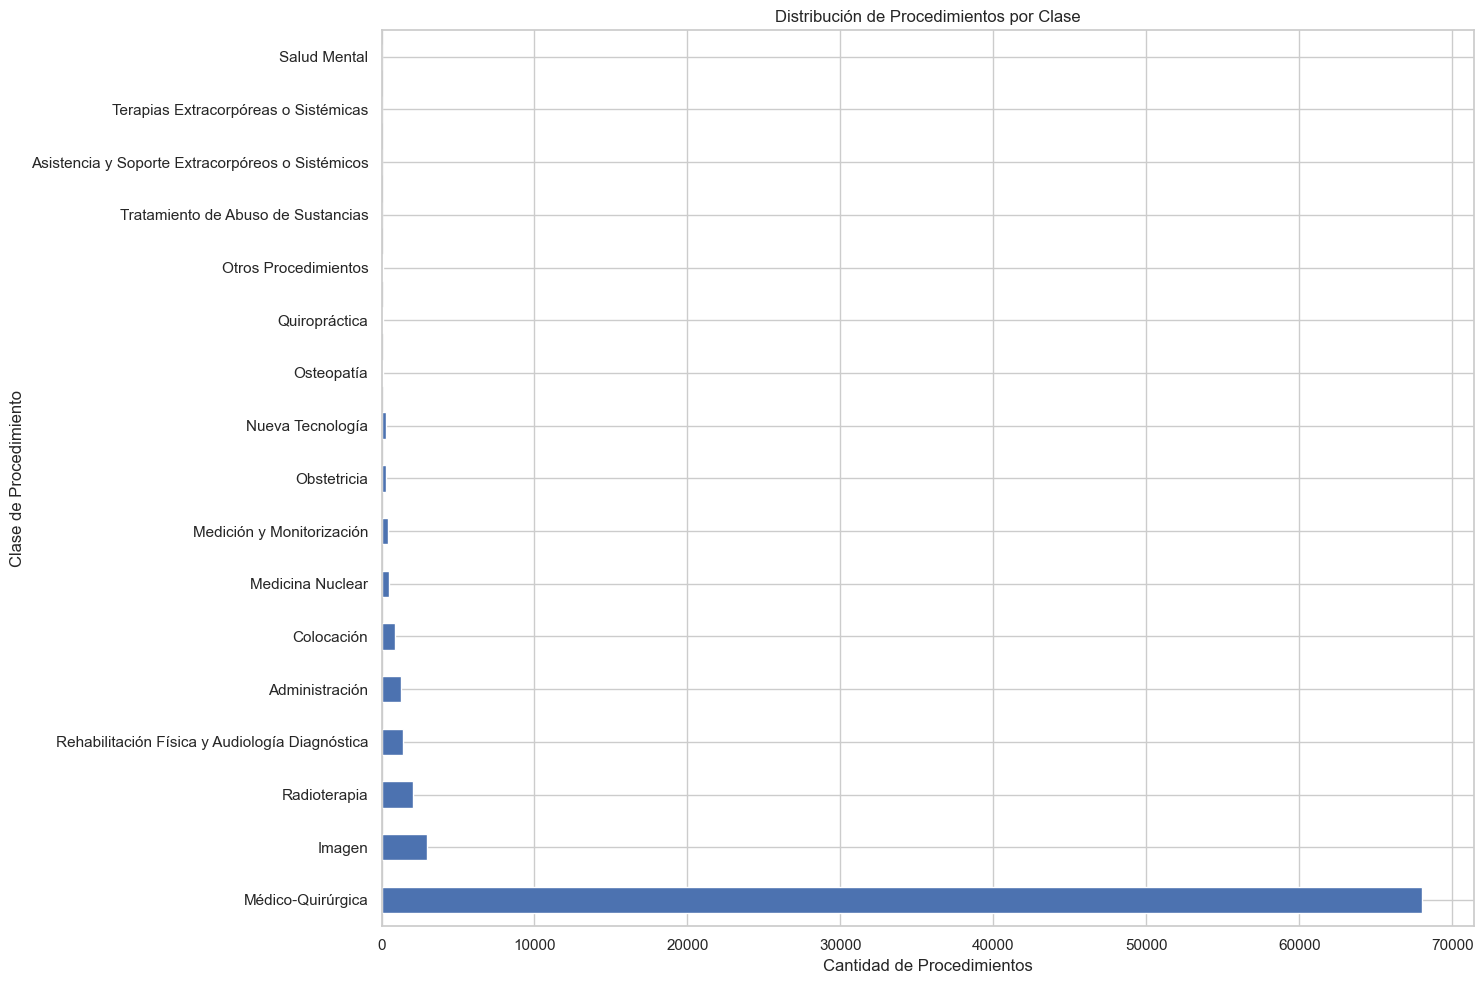

In [6]:
# Exploración inicial de datos de procedimientos
print(f"Dimensiones del dataset de procedimientos: {df_procedimientos.shape}")
print("\nInformación del dataset de procedimientos:")
display(df_procedimientos.info())
print("\nResumen estadístico del dataset de procedimientos:")
display(df_procedimientos.describe())
print("\nPrimeras filas del dataset de procedimientos:")
display(df_procedimientos.head())

# Verificar valores nulos
print("\nValores nulos por columna en el dataset de procedimientos:")
display(df_procedimientos.isnull().sum())

# Distribución de clases de procedimientos
if 'class_name' in df_procedimientos.columns:
    print("\nDistribución de procedimientos por clase:")
    class_counts = df_procedimientos['class_name'].value_counts()
    display(class_counts)

    # Visualización de la distribución de clases
    plt.figure(figsize=(15, 10))
    class_counts.plot(kind='barh')
    plt.title('Distribución de Procedimientos por Clase')
    plt.xlabel('Cantidad de Procedimientos')
    plt.ylabel('Clase de Procedimiento')
    plt.tight_layout()
    plt.show()

### 2.3 Exploración de Datos CIE-10-ES Químicos

Dimensiones del dataset de químicos: (5050, 18)

Información del dataset de químicos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   area         5050 non-null   object 
 1   code1        4890 non-null   object 
 2   code2        4890 non-null   object 
 3   code3        4890 non-null   object 
 4   code4        4890 non-null   object 
 5   code5        4864 non-null   object 
 6   code6        5008 non-null   object 
 7   codes        10 non-null     object 
 8   description  5050 non-null   object 
 9   fatherId     5050 non-null   int64  
 10  finalNode    5050 non-null   int64  
 11  id           5050 non-null   int64  
 12  indx         5050 non-null   object 
 13  level        5050 non-null   int64  
 14  notes        0 non-null      float64
 15  orderList    5050 non-null   float64
 16  path         5050 non-null   object 
 17  tab 

None


Resumen estadístico del dataset de químicos:


,fatherId,finalNode,id,level,notes,orderList,tab
count,5050.0,5050.000000,5050.000000,5050.0,0.0,5050.000000,0.0
mean,0.0,0.879604,88436.876238,0.0,NaN,114124.602376,NaN
std,0.0,0.325456,2510.602820,0.0,NaN,2106.127043,NaN
min,0.0,0.000000,84634.000000,0.0,NaN,110357.000000,NaN
25%,0.0,1.000000,86574.250000,0.0,NaN,112309.250000,NaN
50%,0.0,1.000000,88370.500000,0.0,NaN,114130.500000,NaN
75%,0.0,1.000000,90090.750000,0.0,NaN,115857.750000,NaN
max,0.0,1.000000,117268.000000,0.0,NaN,117859.000000,NaN



Primeras filas del dataset de químicos:


,area,code1,code2,code3,code4,code5,code6,codes,description,fatherId,finalNode,id,indx,level,notes,orderList,path,tab
0,0,T40.2X1,T40.2X2,T40.2X3,T40.2X4,T40.2X5,T40.2X6,NaN,14-hidroxidihidro-morfinona,0,1,84634,F,0,NaN,110357.0,"0,84634,",NaN
1,0,T51.3X1,T51.3X2,T51.3X3,T51.3X4,-,--,NaN,1-Propanol,0,1,84636,F,0,NaN,110359.0,"0,84636,",NaN
2,0,T53.7X1,T53.7X2,T53.7X3,T53.7X4,-,--,NaN,"2,3,7,8-Tetraclorodi-benzo-p-dioxina",0,1,84637,F,0,NaN,110360.0,"0,84637,",NaN
3,0,T60.1X1,T60.1X2,T60.1X3,T60.1X4,-,--,NaN,"2,4,5-T (ácido tricloro-fenoxiacético)",0,1,84639,F,0,NaN,110362.0,"0,84639,",NaN
4,0,T60.3X1,T60.3X2,T60.3X3,T60.3X4,-,--,NaN,"2,4,5-Triclorofenoxiacético, ácido",0,1,84640,F,0,NaN,110363.0,"0,84640,",NaN



Valores nulos por columna en el dataset de químicos:


area              0
code1           160
code2           160
code3           160
code4           160
code5           186
code6            42
codes          5040
description       0
fatherId          0
finalNode         0
id                0
indx              0
level             0
notes          5050
orderList         0
path              0
tab            5050
dtype: int64


Distribución de químicos por categoría principal (primera letra del código):


primera_letra_codigo
T    4890
Name: count, dtype: int64

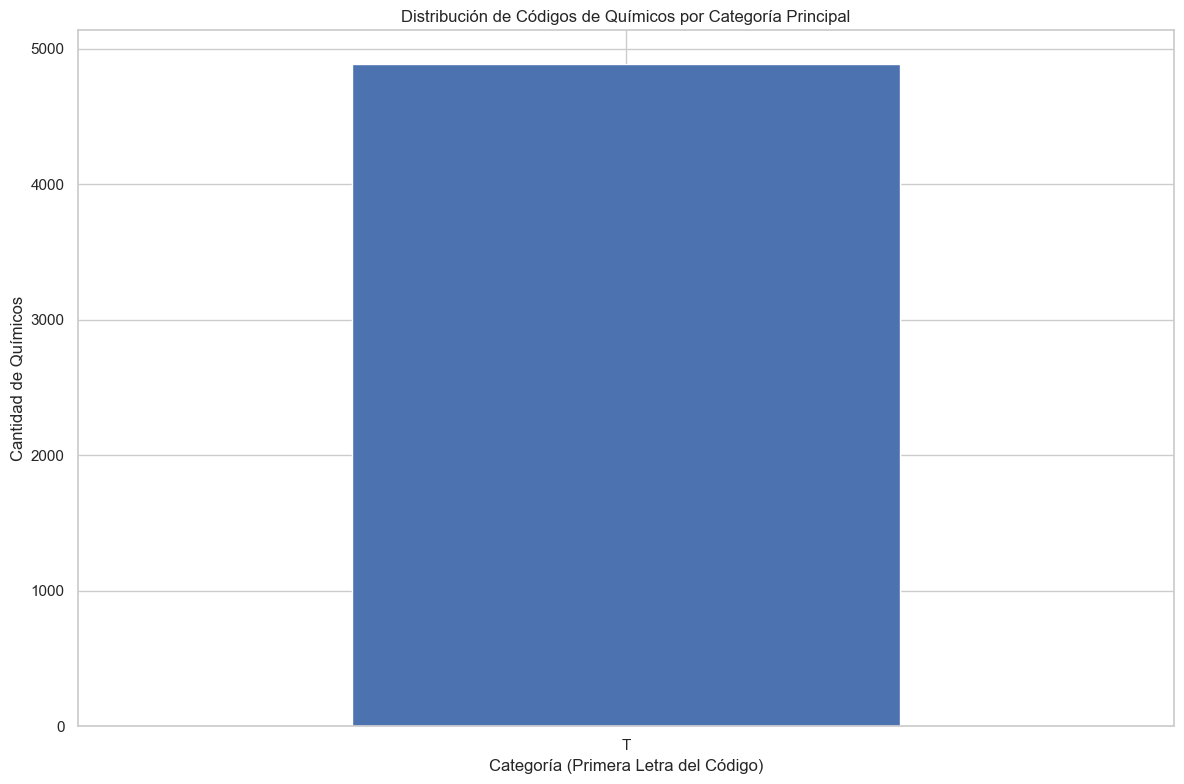

In [7]:
# Exploración inicial de datos de químicos
print(f"Dimensiones del dataset de químicos: {df_quimicos.shape}")
print("\nInformación del dataset de químicos:")
display(df_quimicos.info())
print("\nResumen estadístico del dataset de químicos:")
display(df_quimicos.describe())
print("\nPrimeras filas del dataset de químicos:")
display(df_quimicos.head())

# Verificar valores nulos
print("\nValores nulos por columna en el dataset de químicos:")
display(df_quimicos.isnull().sum())

# Análisis de códigos de químicos
if 'code1' in df_quimicos.columns:
    # Extraer la primera letra del código para categorización
    df_quimicos['primera_letra_codigo'] = df_quimicos['code1'].str[0] if not df_quimicos['code1'].isnull().all() else None

    if df_quimicos['primera_letra_codigo'] is not None:
        print("\nDistribución de químicos por categoría principal (primera letra del código):")
        letter_counts = df_quimicos['primera_letra_codigo'].value_counts().sort_index()
        display(letter_counts)

        # Visualización
        plt.figure(figsize=(12, 8))
        letter_counts.plot(kind='bar')
        plt.title('Distribución de Códigos de Químicos por Categoría Principal')
        plt.xlabel('Categoría (Primera Letra del Código)')
        plt.ylabel('Cantidad de Químicos')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

### 2.4 Exploración de Datos CODIESP


Análisis del conjunto CODIESP train
Dimensiones del dataset CODIESP train: (500, 2)

Información del dataset CODIESP train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    500 non-null    object
 1   labels  500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


None


Valores nulos por columna en el dataset CODIESP train:


text      0
labels    0
dtype: int64


Primera fila del dataset CODIESP train:


,text,labels
0,Describimos el caso de un varón de 37 años con...,"['n44.8', 'z20.818', 'r60.9', 'r52', 'a23.9', ..."



Número total de etiquetas en el dataset train: 5639
Número de etiquetas únicas en el dataset train: 1768

Etiquetas más frecuentes en el dataset train:

Etiquetas más frecuentes en el dataset train:


r52       112
r69        99
r50.9      97
i10        77
r60.9      66
r59.9      65
r53.1      57
r11.10     47
r10.9      46
r59.0      46
Name: count, dtype: int64

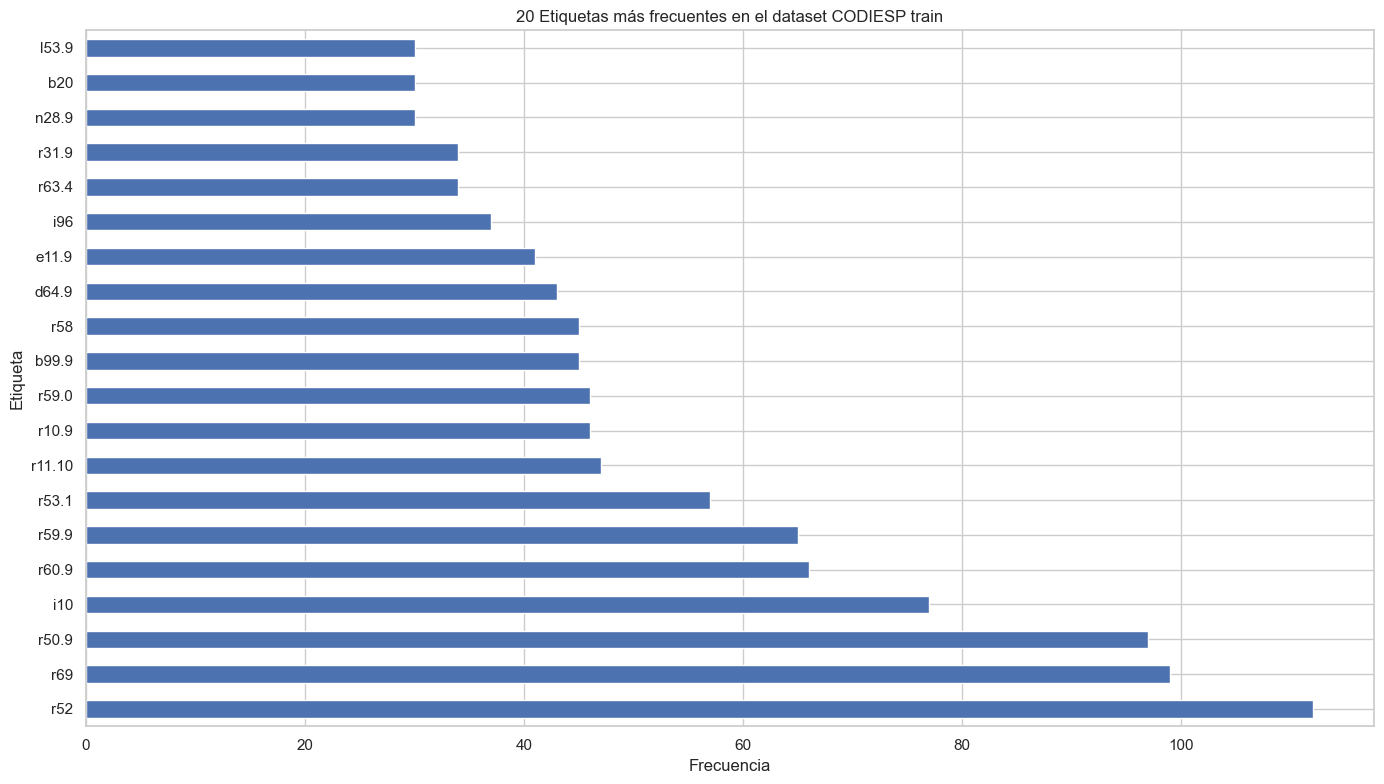


Análisis del conjunto CODIESP test
Dimensiones del dataset CODIESP test: (250, 2)

Información del dataset CODIESP test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    250 non-null    object
 1   labels  250 non-null    object
dtypes: object(2)
memory usage: 4.0+ KB


None


Valores nulos por columna en el dataset CODIESP test:


text      0
labels    0
dtype: int64


Primera fila del dataset CODIESP test:


,text,labels
0,"Paciente de 70 años de edad, minero jubilado, ...","['s22.49xa', 'n28.1', 'r69', 'f17.210', 'r31.9..."



Número total de etiquetas en el dataset test: 2842
Número de etiquetas únicas en el dataset test: 1143

Etiquetas más frecuentes en el dataset test:


r52      56
r50.9    49
r69      48
i10      45
r59.9    41
r60.9    33
r58      28
r10.9    28
r59.0    27
e11.9    25
Name: count, dtype: int64

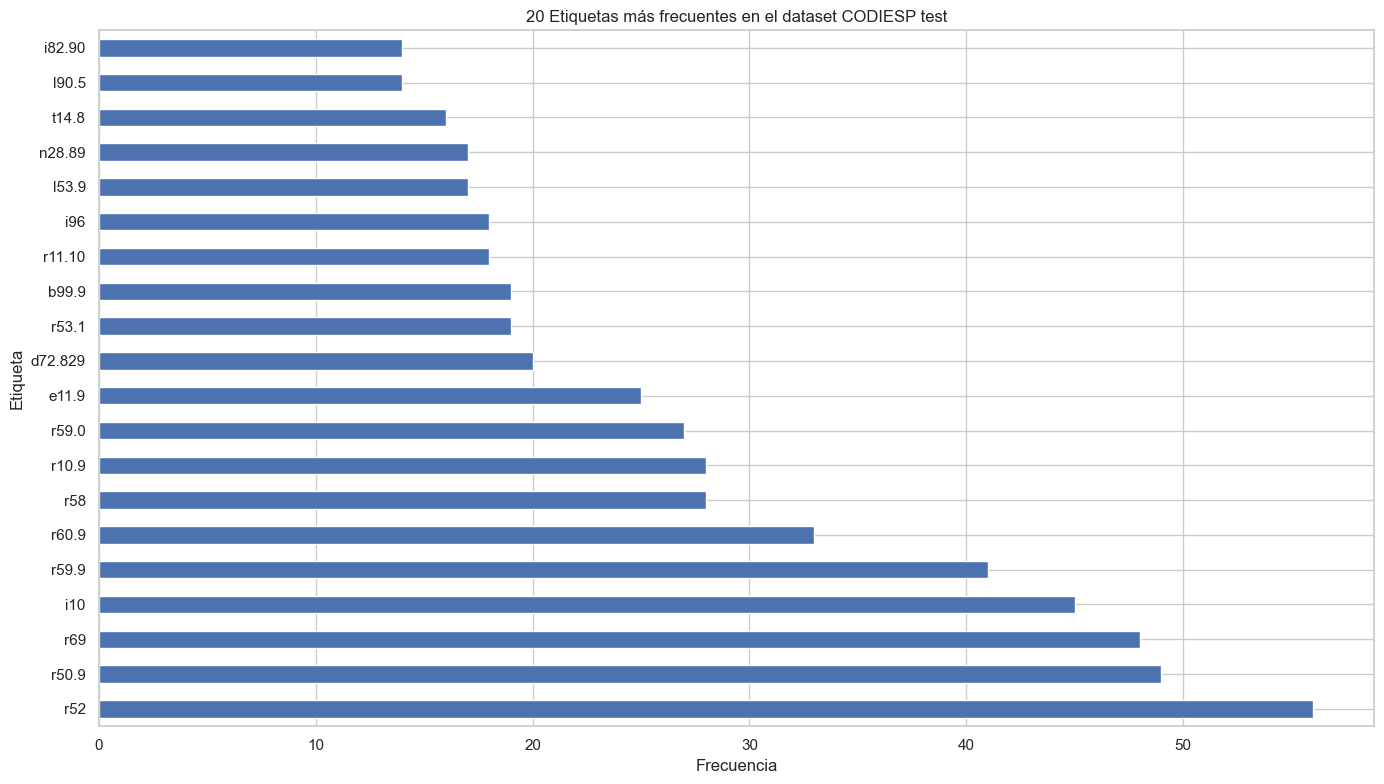


Análisis del conjunto CODIESP validation
Dimensiones del dataset CODIESP validation: (250, 2)

Información del dataset CODIESP validation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    250 non-null    object
 1   labels  250 non-null    object
dtypes: object(2)
memory usage: 4.0+ KB


None


Valores nulos por columna en el dataset CODIESP validation:


text      0
labels    0
dtype: int64


Primera fila del dataset CODIESP validation:


,text,labels
0,Mujer de 29 años con antecedentes de ulcus duo...,"['q62.11', 'n28.89', 'n39.0', 'r31.9', 'n23', ..."



Número total de etiquetas en el dataset validation: 2677
Número de etiquetas únicas en el dataset validation: 1158

Etiquetas más frecuentes en el dataset validation:


r69       51
r52       51
r50.9     45
i10       39
r59.9     30
r11.10    27
b99.9     25
r60.9     25
e11.9     19
r59.0     18
Name: count, dtype: int64

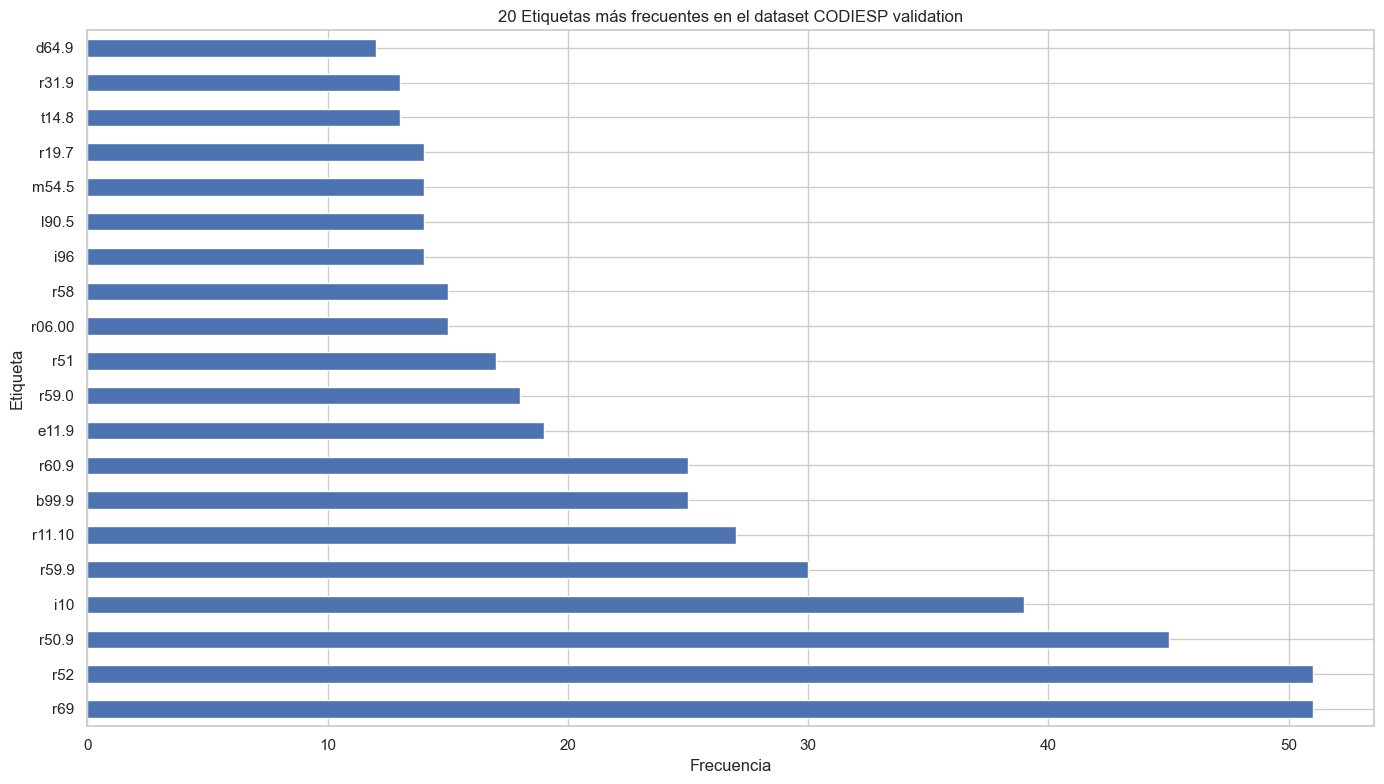

In [8]:
# Función para explorar los conjuntos de datos CODIESP
def explorar_codiesp(nombre_conjunto, df):
    print(f"Dimensiones del dataset CODIESP {nombre_conjunto}: {df.shape}")
    print(f"\nInformación del dataset CODIESP {nombre_conjunto}:")
    display(df.info())

    # Verificar valores nulos
    print(f"\nValores nulos por columna en el dataset CODIESP {nombre_conjunto}:")
    display(df.isnull().sum())

    # Primeras filas
    print(f"\nPrimera fila del dataset CODIESP {nombre_conjunto}:")
    display(df.head(1))

    # Análisis de etiquetas
    if 'labels' in df.columns:
        # Extraer y contar las etiquetas únicas
        todas_etiquetas = []
        for labels_str in df['labels']:
            try:
                # Convertir la cadena de texto que representa la lista a una lista real
                labels_list = eval(labels_str)
                todas_etiquetas.extend(labels_list)
            except:
                print(f"Error al procesar etiquetas: {labels_str}")
                continue

        print(f"\nNúmero total de etiquetas en el dataset {nombre_conjunto}: {len(todas_etiquetas)}")
        print(f"Número de etiquetas únicas en el dataset {nombre_conjunto}: {len(set(todas_etiquetas))}")

        # Frecuencia de las etiquetas principales (mostrar las 10 más comunes)
        etiquetas_counter = pd.Series(todas_etiquetas).value_counts()
        print(f"\nEtiquetas más frecuentes en el dataset {nombre_conjunto}:")
        display(etiquetas_counter.head(10))

        # Visualización de etiquetas más comunes
        plt.figure(figsize=(14, 8))
        etiquetas_counter.head(20).plot(kind='barh')
        plt.title(f'20 Etiquetas más frecuentes en el dataset CODIESP {nombre_conjunto}')
        plt.xlabel('Frecuencia')
        plt.ylabel('Etiqueta')
        plt.tight_layout()
        plt.show()

        return etiquetas_counter
    else:
        print("No se encontró la columna 'labels' en el dataset.")
        return None

# Explorar cada conjunto de datos CODIESP
etiquetas_por_conjunto = {}
for nombre, df in dfs_codiesp.items():
    print(f"\n{'='*50}\nAnálisis del conjunto CODIESP {nombre}\n{'='*50}")
    etiquetas_por_conjunto[nombre] = explorar_codiesp(nombre, df)

## 3. Análisis Estadístico Descriptivo

En esta sección realizaremos un análisis estadístico descriptivo de los datos para entender mejor sus características.

Análisis Descriptivo de Diagnósticos CIE-10-ES
Número total de registros: 101246
Número total de columnas: 10

Estadísticas de longitud de descripciones:


count    101246.000000
mean         85.352123
std          46.372936
min           3.000000
25%          55.000000
50%          78.000000
75%         111.000000
max        1354.000000
Name: longitud_descripcion, dtype: float64

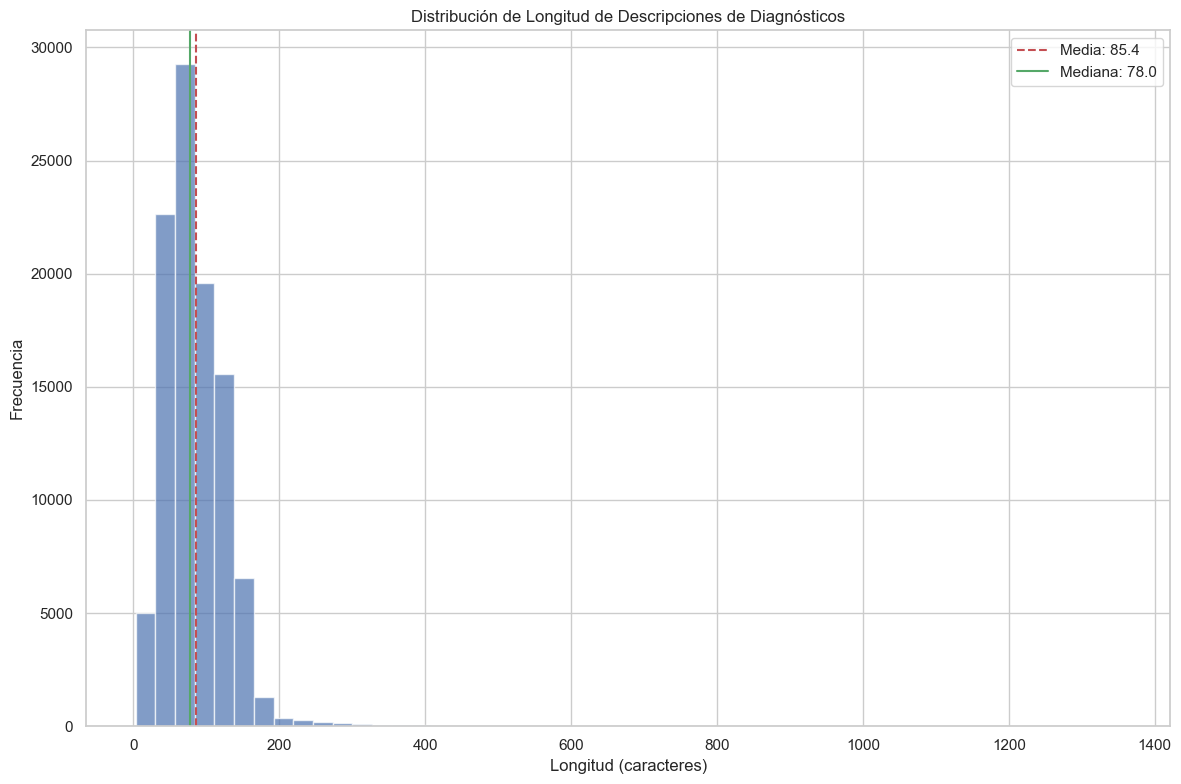


Análisis de columnas binarias (frecuencias de valores 1):
perinatal: 0.04% de los registros tienen valor 1
pediatric: 0.11% de los registros tienen valor 1
maternity: 2.51% de los registros tienen valor 1
adult: 0.82% de los registros tienen valor 1
poaExempt: 37.19% de los registros tienen valor 1
noPrincipal: 9.54% de los registros tienen valor 1
vcdp: 0.77% de los registros tienen valor 1


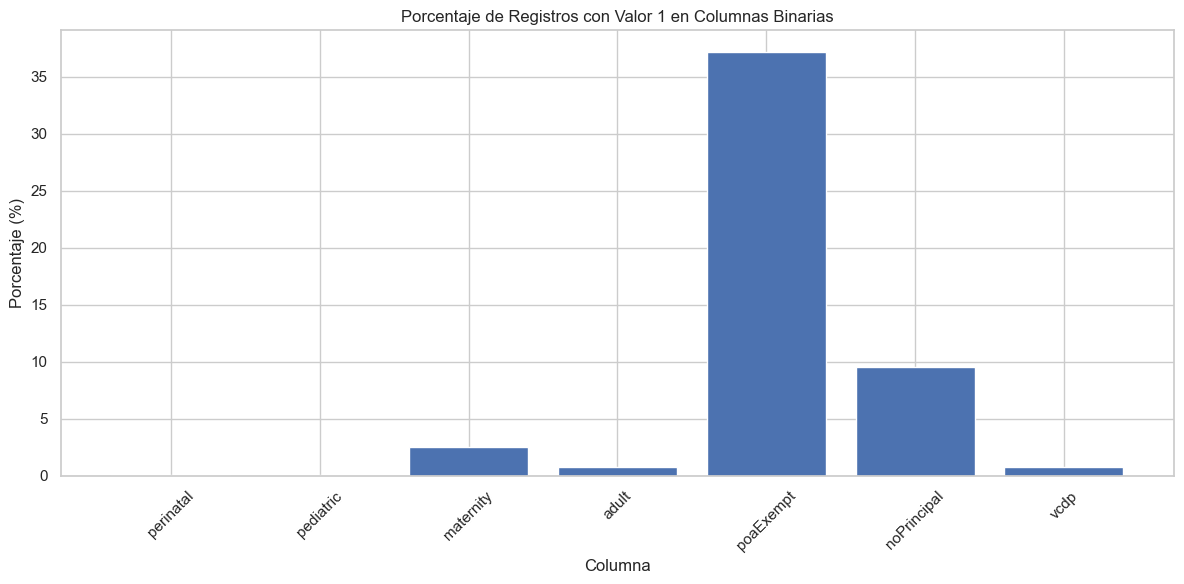

In [9]:
# Análisis estadístico descriptivo para el dataset de diagnósticos
def analisis_descriptivo_diagnosticos():
    print("Análisis Descriptivo de Diagnósticos CIE-10-ES")
    print("=" * 50)

    # Estadísticas generales
    print(f"Número total de registros: {df_diagnosticos.shape[0]}")
    print(f"Número total de columnas: {df_diagnosticos.shape[1]}")

    # Análisis de longitud de las descripciones
    if 'description' in df_diagnosticos.columns:
        df_diagnosticos['longitud_descripcion'] = df_diagnosticos['description'].str.len()

        print("\nEstadísticas de longitud de descripciones:")
        desc_stats = df_diagnosticos['longitud_descripcion'].describe()
        display(desc_stats)

        # Histograma de longitud de descripciones
        plt.figure(figsize=(12, 8))
        plt.hist(df_diagnosticos['longitud_descripcion'], bins=50, alpha=0.7)
        plt.axvline(desc_stats['mean'], color='r', linestyle='--', label=f"Media: {desc_stats['mean']:.1f}")
        plt.axvline(desc_stats['50%'], color='g', linestyle='-', label=f"Mediana: {desc_stats['50%']:.1f}")
        plt.title('Distribución de Longitud de Descripciones de Diagnósticos')
        plt.xlabel('Longitud (caracteres)')
        plt.ylabel('Frecuencia')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Análisis de columnas binarias si existen
    columnas_binarias = ['perinatal', 'pediatric', 'maternity', 'adult', 'poaExempt', 'noPrincipal', 'vcdp']
    columnas_presentes = [col for col in columnas_binarias if col in df_diagnosticos.columns]

    if columnas_presentes:
        print("\nAnálisis de columnas binarias (frecuencias de valores 1):")
        for columna in columnas_presentes:
            if df_diagnosticos[columna].dtype in ['int64', 'float64']:
                valor_1_pct = (df_diagnosticos[columna] == 1).mean() * 100
                print(f"{columna}: {valor_1_pct:.2f}% de los registros tienen valor 1")

        # Gráfico de barras para columnas binarias
        valores_1_pct = [(df_diagnosticos[col] == 1).mean() * 100 for col in columnas_presentes]
        plt.figure(figsize=(12, 6))
        plt.bar(columnas_presentes, valores_1_pct)
        plt.title('Porcentaje de Registros con Valor 1 en Columnas Binarias')
        plt.xlabel('Columna')
        plt.ylabel('Porcentaje (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Ejecutar análisis descriptivo de diagnósticos
analisis_descriptivo_diagnosticos()

Análisis Descriptivo de Procedimientos CIE-10-ES
Número total de registros: 78496
Número total de columnas: 13

Estadísticas de 'timesSelected' (frecuencia de selección):


count    78496.000000
mean       106.224126
std        711.709785
min          4.000000
25%          7.000000
50%         11.000000
75%         30.000000
max      40199.000000
Name: timesSelected, dtype: float64

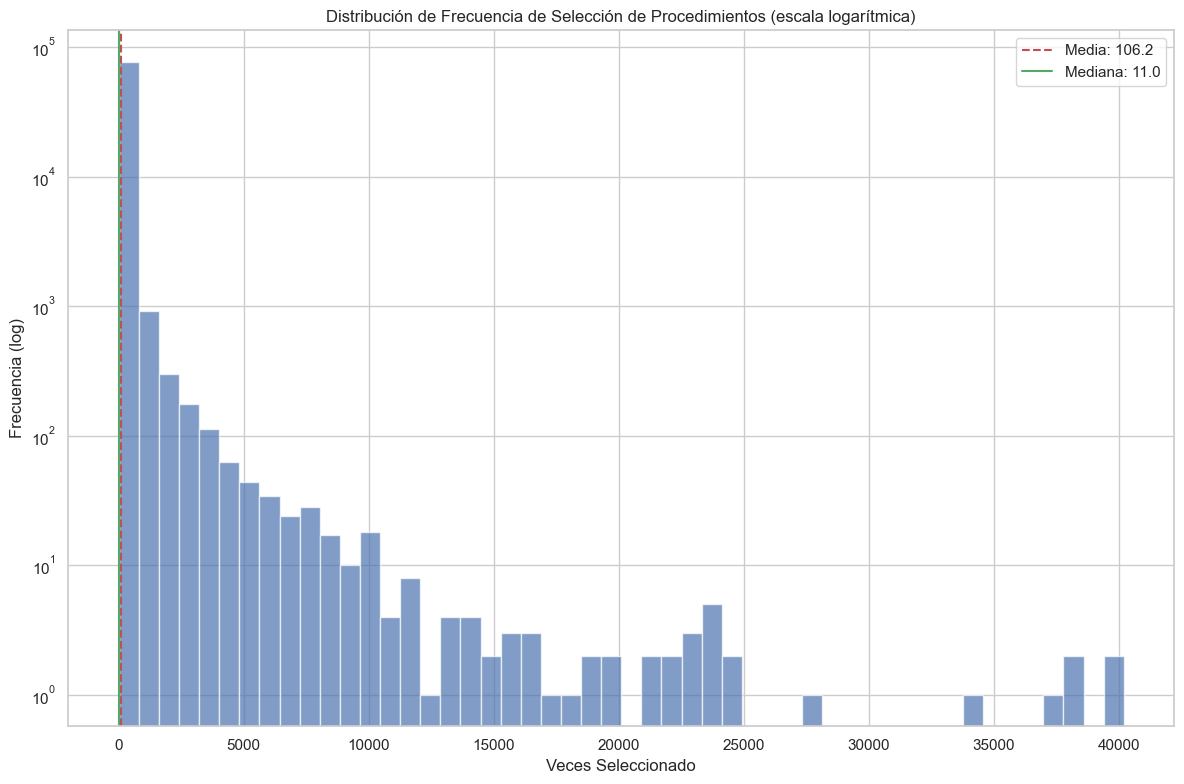


Top 10 Procedimientos Más Seleccionados:


,code,description,timesSelected
74165,BW40ZZZ,Ecografía de abdomen,40199
36237,0HB1XZZ,"Escisión de piel, cara, abordaje externo",39448
71357,B020ZZZ,Tomografía computarizada (scanner tc) de cerebro,38583
31234,0DJD8ZZ,"Inspección de tracto intestinal inferior, abor...",38564
69947,3E03329,Introducción en vena periférica de anti-infecc...,37158
74171,BW03ZZZ,Radiografía simple de tórax,34524
4247,027034Z,"Dilatación de arteria coronaria, una arteria, ...",27928
30758,0DB68ZX,"Escisión de estómago, diagnóstico, abordaje or...",24394
69960,3E033GC,Introducción en vena periférica de otra sustan...,24319
58820,0T9B70Z,"Drenaje en vejiga, con dispositivo de drenaje,...",23908



Distribución de procedimientos por class_name:


class_name
Médico-Quirúrgica                                 68024
Imagen                                             2978
Radioterapia                                       2056
Rehabilitación Física y Audiología Diagnóstica     1380
Administración                                     1257
Colocación                                          861
Medicina Nuclear                                    463
Medición y Monitorización                           422
Obstetricia                                         304
Nueva Tecnología                                    297
Name: count, dtype: int64

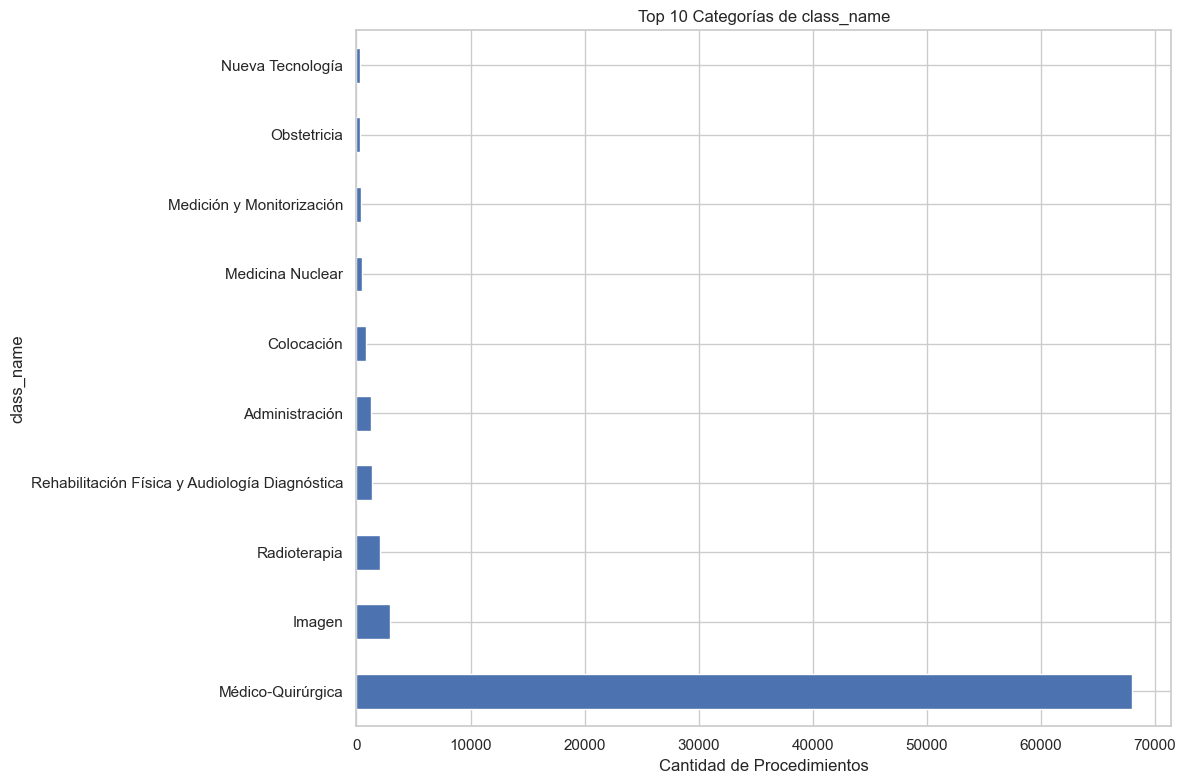


Distribución de procedimientos por subclass_name:


subclass_name
Arterias Inferiores          5209
Sistema Gastrointestinal     4818
Arterias Superiores          4220
Articulaciones Superiores    4087
Articulaciones Inferiores    3383
Corazón y Grandes Vasos      3071
Huesos Superiores            2907
Huesos Inferiores            2898
Sistema Respiratorio         2590
Venas Superiores             2486
Name: count, dtype: int64

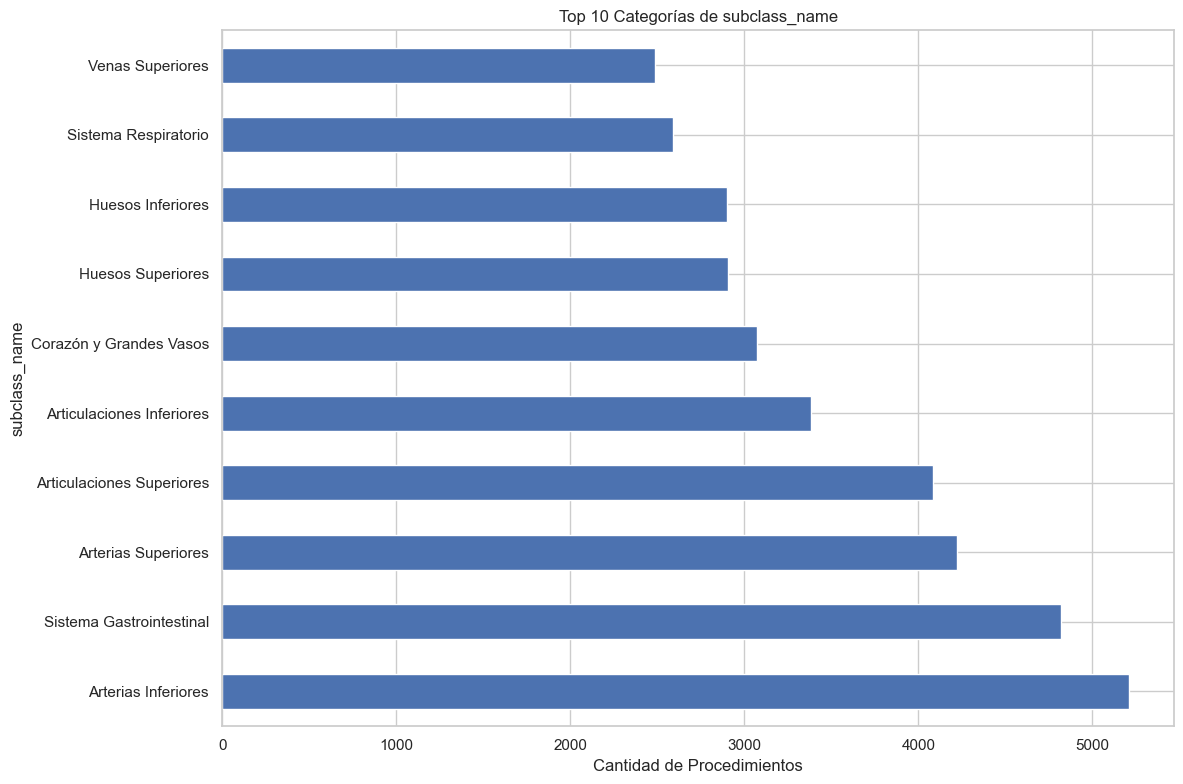


Distribución de procedimientos por procedure:


procedure
Drenaje        6864
Derivación     5817
Revisión       5778
Retirada       5547
Suplemento     5365
Escisión       4609
Inserción      4076
Sustitución    3580
Dilatación     3430
Reparación     2758
Name: count, dtype: int64

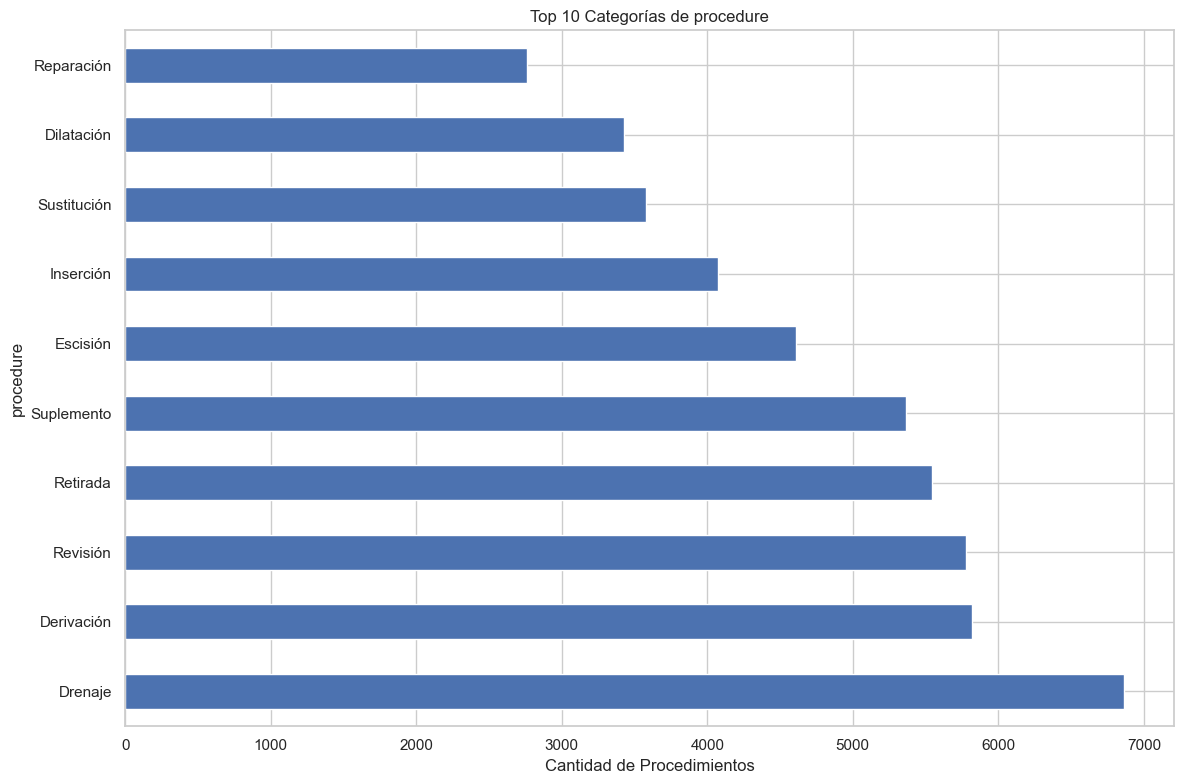


Distribución de procedimientos por approach:


approach
Abierto                                       22916
Endoscópico Percutáneo                        19284
Percutáneo                                    17261
Externo                                        5599
Orificio Natural o Artificial, Endoscópico     3565
Orificio Natural o Artificial                  2792
Ninguno                                         989
Otro Contraste                                  894
Baja Osmolaridad                                581
Hiperosmolar                                    581
Name: count, dtype: int64

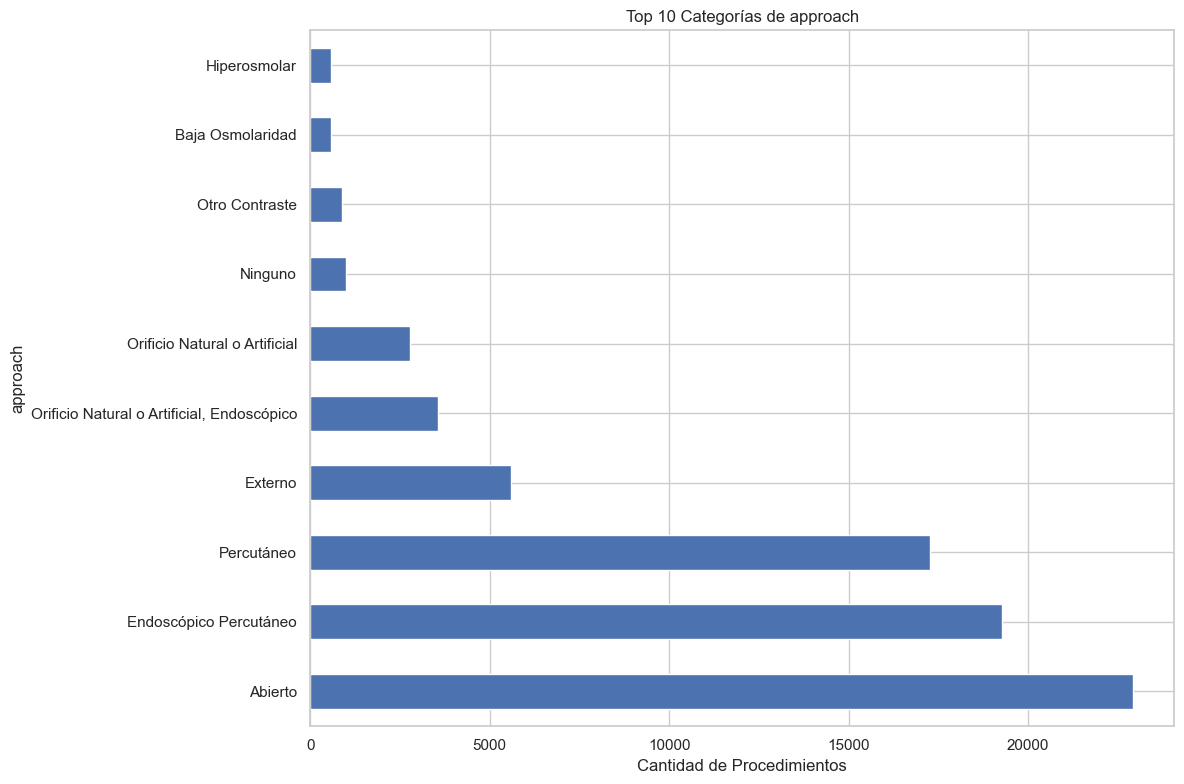


Distribución de procedimientos por device:


device
Ninguno                            34135
Sustituto Sintético                 6120
Sustituto de Tejido No Autólogo     5750
Sustituto de Tejido Autólogo        5236
Dispositivo de Drenaje              3729
Dispositivo Intraluminal            3226
Dispositivo de Infusión             1997
Dispositivo de Fijación Interna     1685
Otro Dispositivo                    1527
Dispositivo Extraluminal            1455
Name: count, dtype: int64

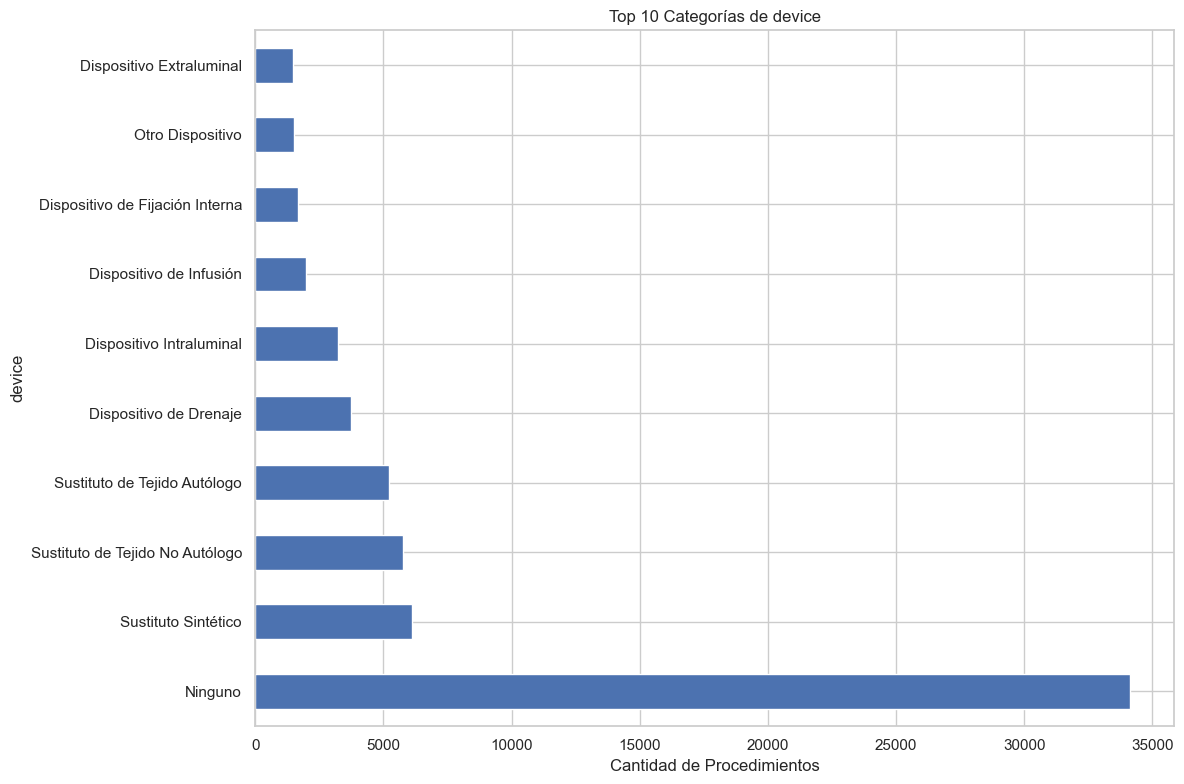


Distribución de procedimientos por calification:


calification
Ninguno                                   62990
Diagnóstico                                4819
Balón Recubierto de Fármaco                 429
Vena Superior                               312
Vena Inferior                               289
Cutáneo                                     265
Intraoperatoria                             247
Terapia Térmica Intersticial con Láser      222
Arteria Extremidad Inferior                 175
Íleon                                       136
Name: count, dtype: int64

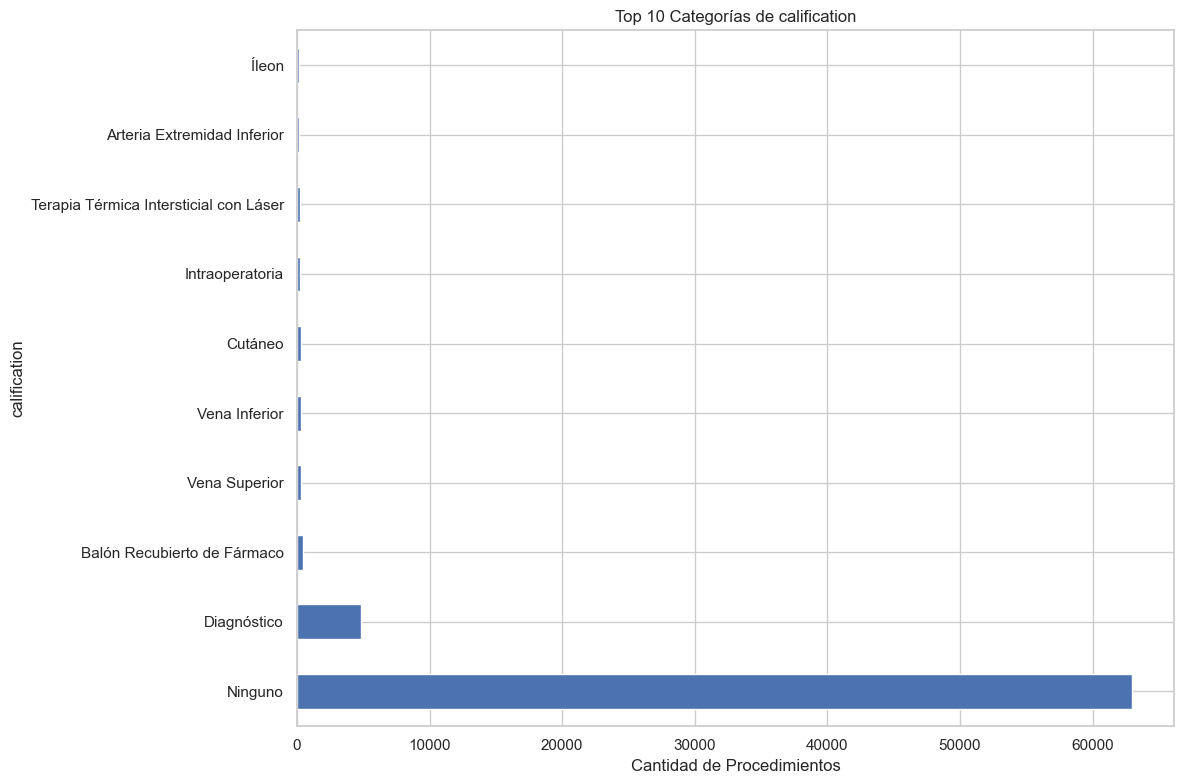

In [10]:
# Análisis estadístico descriptivo para el dataset de procedimientos
def analisis_descriptivo_procedimientos():
    print("Análisis Descriptivo de Procedimientos CIE-10-ES")
    print("=" * 50)

    # Estadísticas generales
    print(f"Número total de registros: {df_procedimientos.shape[0]}")
    print(f"Número total de columnas: {df_procedimientos.shape[1]}")

    # Análisis de columnas numéricas si existen
    if 'timesSelected' in df_procedimientos.columns:
        print("\nEstadísticas de 'timesSelected' (frecuencia de selección):")
        times_stats = df_procedimientos['timesSelected'].describe()
        display(times_stats)

        # Histograma de veces seleccionadas
        plt.figure(figsize=(12, 8))
        # Usamos escala logarítmica debido a la posible distribución sesgada
        plt.hist(df_procedimientos['timesSelected'], bins=50, alpha=0.7, log=True)
        plt.axvline(times_stats['mean'], color='r', linestyle='--', label=f"Media: {times_stats['mean']:.1f}")
        plt.axvline(times_stats['50%'], color='g', linestyle='-', label=f"Mediana: {times_stats['50%']:.1f}")
        plt.title('Distribución de Frecuencia de Selección de Procedimientos (escala logarítmica)')
        plt.xlabel('Veces Seleccionado')
        plt.ylabel('Frecuencia (log)')
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Top 10 procedimientos más seleccionados
        print("\nTop 10 Procedimientos Más Seleccionados:")
        top_procedures = df_procedimientos.nlargest(10, 'timesSelected')
        display(top_procedures[['code', 'description', 'timesSelected']] if 'description' in df_procedimientos.columns
                else top_procedures[['code', 'timesSelected']])

    # Análisis de distribución por categorías
    categorias = ['class_name', 'subclass_name', 'procedure', 'approach', 'device', 'calification']
    categorias_presentes = [cat for cat in categorias if cat in df_procedimientos.columns]

    for categoria in categorias_presentes:
        print(f"\nDistribución de procedimientos por {categoria}:")
        cat_counts = df_procedimientos[categoria].value_counts().head(10)  # Top 10 más comunes
        display(cat_counts)

        # Gráfico de los más comunes
        plt.figure(figsize=(12, 8))
        cat_counts.plot(kind='barh')
        plt.title(f'Top 10 Categorías de {categoria}')
        plt.xlabel('Cantidad de Procedimientos')
        plt.ylabel(categoria)
        plt.tight_layout()
        plt.show()

# Ejecutar análisis descriptivo de procedimientos
analisis_descriptivo_procedimientos()

Análisis Descriptivo de Químicos CIE-10-ES
Número total de registros: 5050
Número total de columnas: 19

Estadísticas de longitud de descripciones de químicos:


count    5050.000000
mean       14.397624
std         8.527211
min         3.000000
25%         9.000000
50%        11.000000
75%        17.000000
max       102.000000
Name: longitud_descripcion, dtype: float64

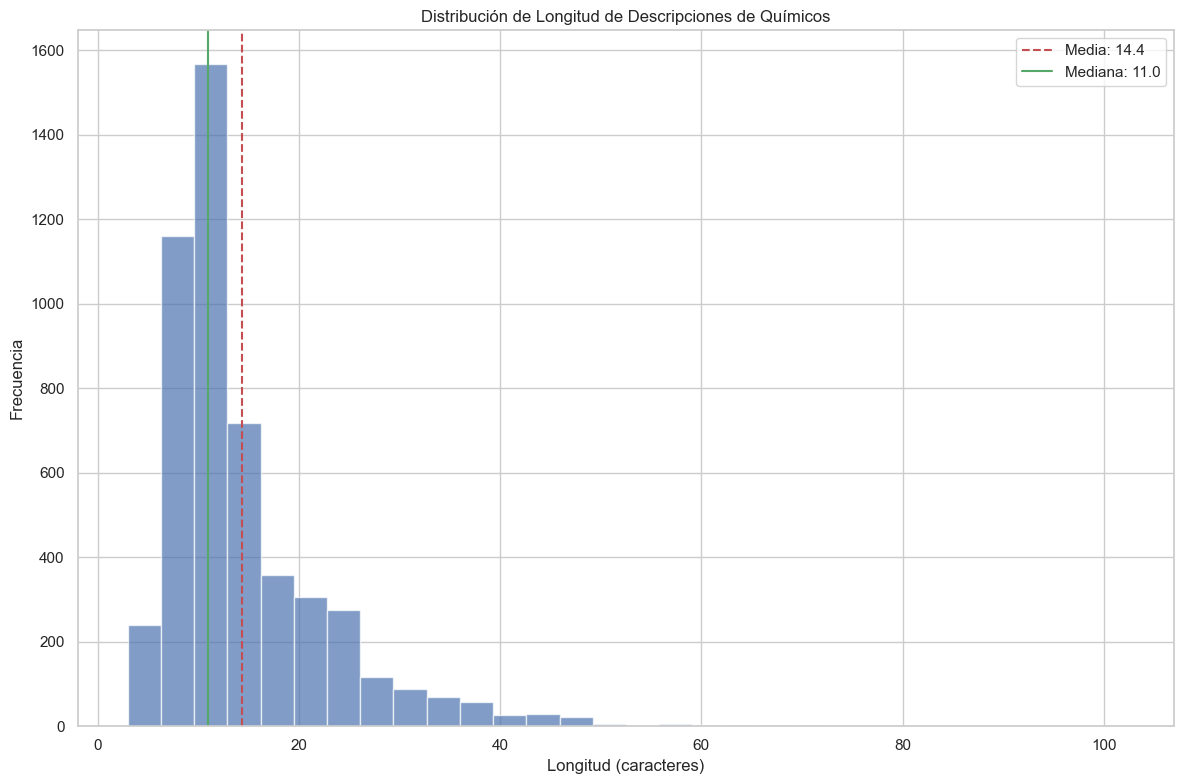


Análisis de códigos múltiples:


0      16
1     144
4      26
6    4864
Name: count, dtype: int64


Porcentaje de químicos con al menos 2 códigos: 96.83%
Porcentaje de químicos con al menos 4 códigos: 96.83%
Porcentaje de químicos con 6 códigos completos: 96.32%


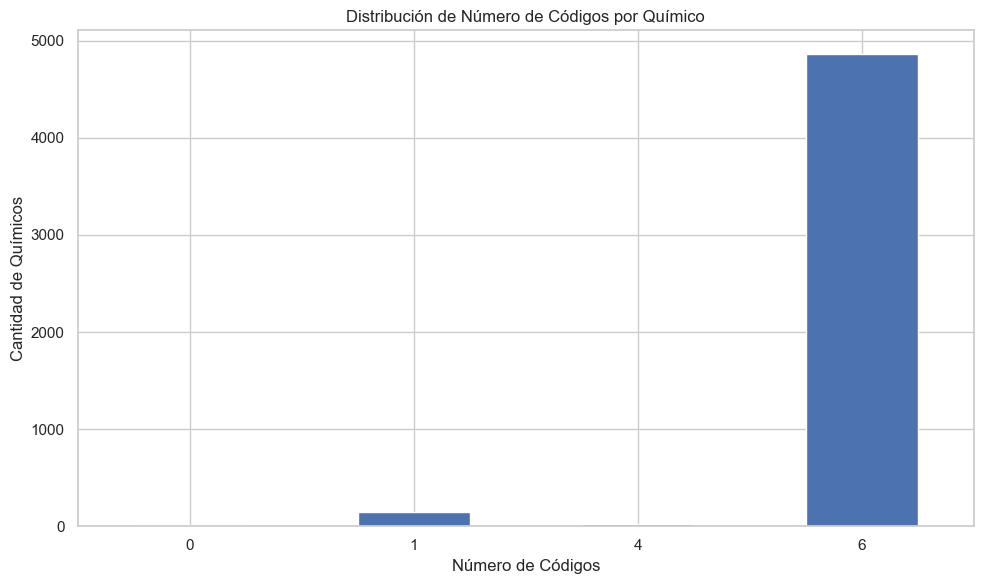

In [11]:
# Análisis estadístico descriptivo para el dataset de químicos
def analisis_descriptivo_quimicos():
    print("Análisis Descriptivo de Químicos CIE-10-ES")
    print("=" * 50)

    # Estadísticas generales
    print(f"Número total de registros: {df_quimicos.shape[0]}")
    print(f"Número total de columnas: {df_quimicos.shape[1]}")

    # Análisis de longitud de las descripciones
    if 'description' in df_quimicos.columns:
        df_quimicos['longitud_descripcion'] = df_quimicos['description'].str.len()

        print("\nEstadísticas de longitud de descripciones de químicos:")
        chem_desc_stats = df_quimicos['longitud_descripcion'].describe()
        display(chem_desc_stats)

        # Histograma de longitud de descripciones
        plt.figure(figsize=(12, 8))
        plt.hist(df_quimicos['longitud_descripcion'], bins=30, alpha=0.7)
        plt.axvline(chem_desc_stats['mean'], color='r', linestyle='--', label=f"Media: {chem_desc_stats['mean']:.1f}")
        plt.axvline(chem_desc_stats['50%'], color='g', linestyle='-', label=f"Mediana: {chem_desc_stats['50%']:.1f}")
        plt.title('Distribución de Longitud de Descripciones de Químicos')
        plt.xlabel('Longitud (caracteres)')
        plt.ylabel('Frecuencia')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Análisis de códigos múltiples
    codigos = ['code1', 'code2', 'code3', 'code4', 'code5', 'code6']
    codigos_presentes = [col for col in codigos if col in df_quimicos.columns]

    if codigos_presentes:
        # Contar cuántos productos químicos tienen múltiples códigos
        print("\nAnálisis de códigos múltiples:")
        num_codigos = df_quimicos[codigos_presentes].notna().sum(axis=1)
        codigos_stats = num_codigos.value_counts().sort_index()
        display(codigos_stats)

        print(f"\nPorcentaje de químicos con al menos 2 códigos: {(num_codigos >= 2).mean() * 100:.2f}%")
        print(f"Porcentaje de químicos con al menos 4 códigos: {(num_codigos >= 4).mean() * 100:.2f}%")
        print(f"Porcentaje de químicos con 6 códigos completos: {(num_codigos == 6).mean() * 100:.2f}%")

        # Visualización
        plt.figure(figsize=(10, 6))
        codigos_stats.plot(kind='bar')
        plt.title('Distribución de Número de Códigos por Químico')
        plt.xlabel('Número de Códigos')
        plt.ylabel('Cantidad de Químicos')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # Análisis del nivel jerárquico si existe
    if 'level' in df_quimicos.columns:
        if df_quimicos['level'].dtype == 'object':
            # Intentar convertir a numérico si es posible
            try:
                df_quimicos['level_num'] = pd.to_numeric(df_quimicos['level'])
                print("\nEstadísticas del nivel jerárquico:")
                level_stats = df_quimicos['level_num'].describe()
                display(level_stats)

                # Visualización de la distribución de niveles
                plt.figure(figsize=(10, 6))
                df_quimicos['level_num'].value_counts().sort_index().plot(kind='bar')
                plt.title('Distribución de Niveles Jerárquicos de Químicos')
                plt.xlabel('Nivel')
                plt.ylabel('Cantidad de Químicos')
                plt.tight_layout()
                plt.show()
            except:
                print("\nNo se pudo convertir la columna 'level' a valores numéricos.")
                # Análisis categórico
                print("Distribución de valores en la columna 'level':")
                display(df_quimicos['level'].value_counts())

# Ejecutar análisis descriptivo de químicos
analisis_descriptivo_quimicos()

Análisis Descriptivo de Datasets CODIESP
Número total de registros en todos los conjuntos CODIESP: 1000

Distribución de registros por conjunto:
- train: 500 registros (50.0%)
- test: 250 registros (25.0%)
- validation: 250 registros (25.0%)


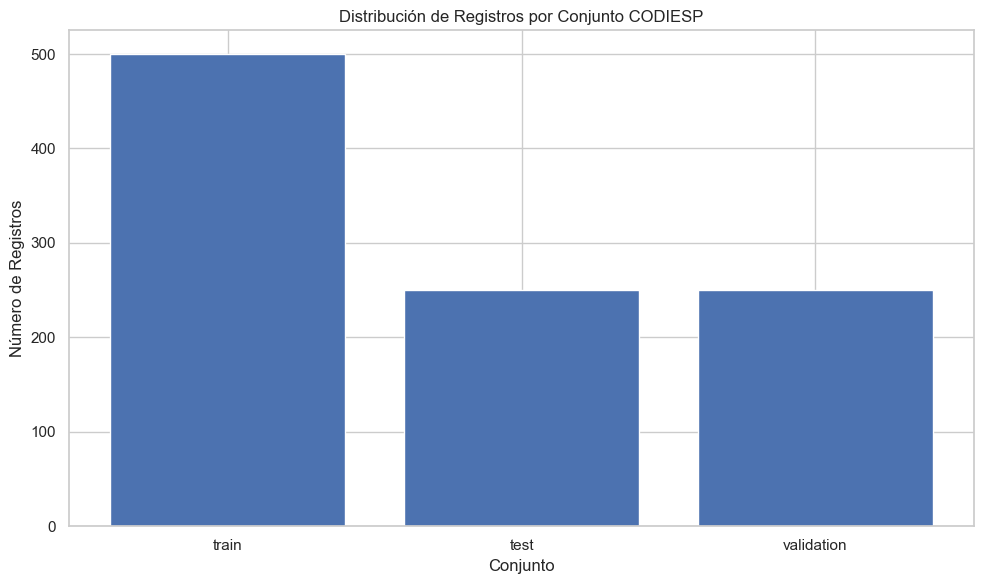


Estadísticas de longitud de textos clínicos:

Conjunto train:


count     500.000000
mean     2317.228000
std      1097.443776
min       556.000000
25%      1516.750000
50%      2100.500000
75%      2885.250000
max      7466.000000
Name: longitud_texto_train, dtype: float64


Conjunto test:


count     250.000000
mean     2359.432000
std      1111.034569
min       555.000000
25%      1546.500000
50%      2209.000000
75%      2962.000000
max      6526.000000
Name: longitud_texto_test, dtype: float64


Conjunto validation:


count     250.000000
mean     2353.964000
std      1116.799843
min       498.000000
25%      1526.500000
50%      2220.000000
75%      2910.000000
max      6010.000000
Name: longitud_texto_validation, dtype: float64

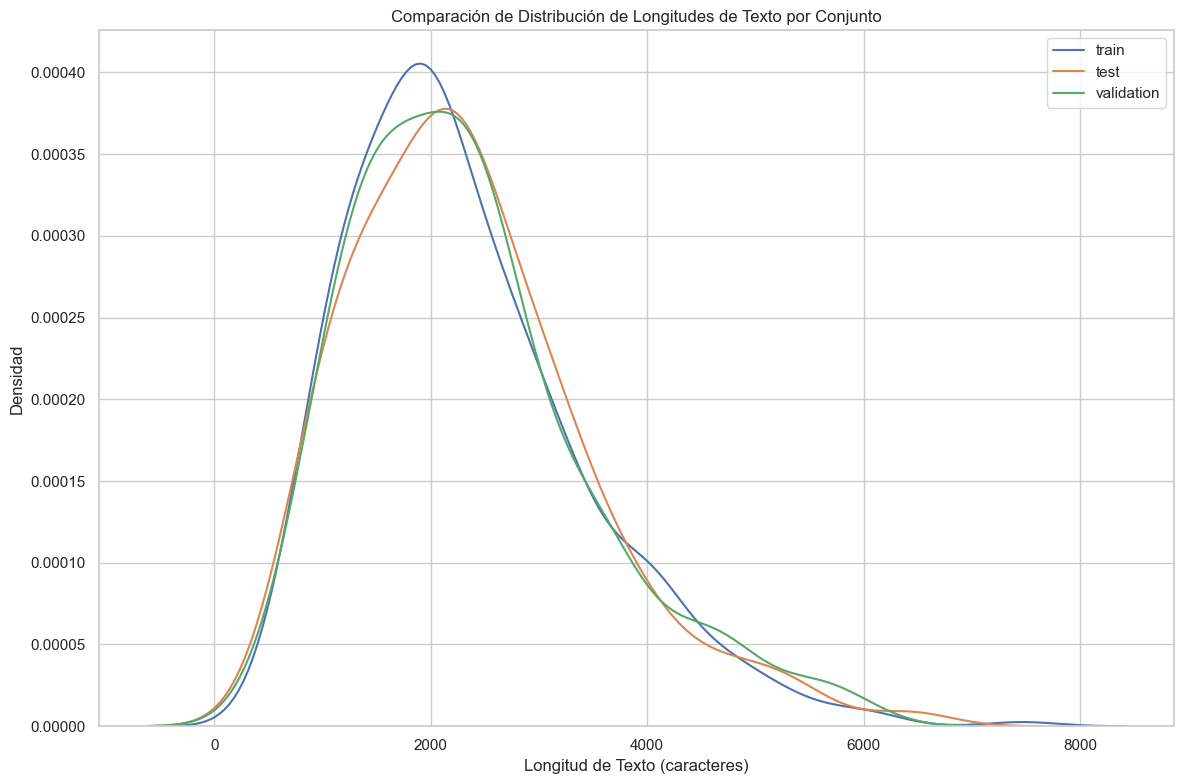


Estadísticas de número de etiquetas por documento:

Conjunto train:


count    500.0000
mean      11.2780
std        6.9453
min        1.0000
25%        6.0000
50%       10.0000
75%       15.0000
max       40.0000
Name: num_etiquetas_train, dtype: float64

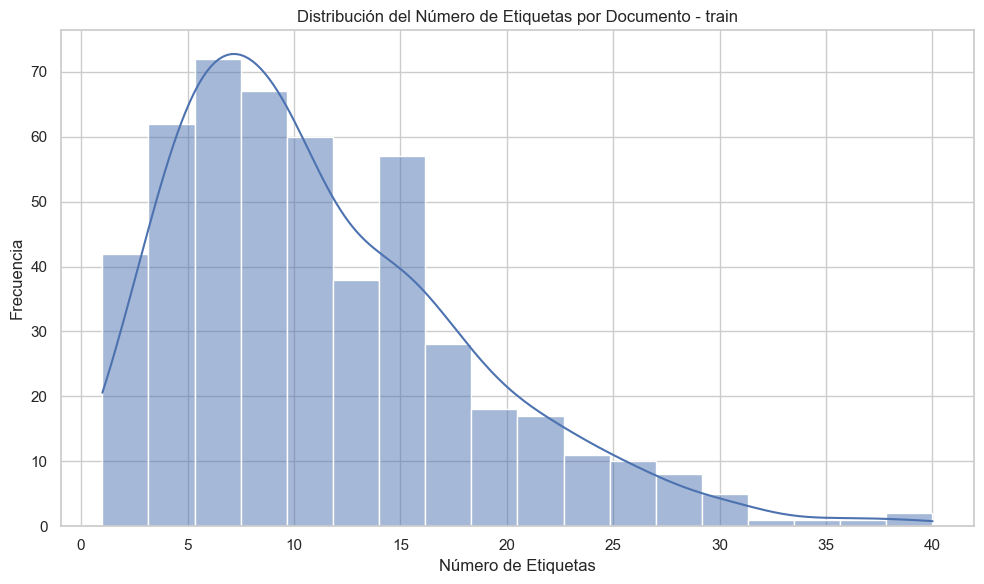


Conjunto test:


count    250.000000
mean      11.368000
std        6.593822
min        1.000000
25%        6.000000
50%       10.000000
75%       15.000000
max       35.000000
Name: num_etiquetas_test, dtype: float64

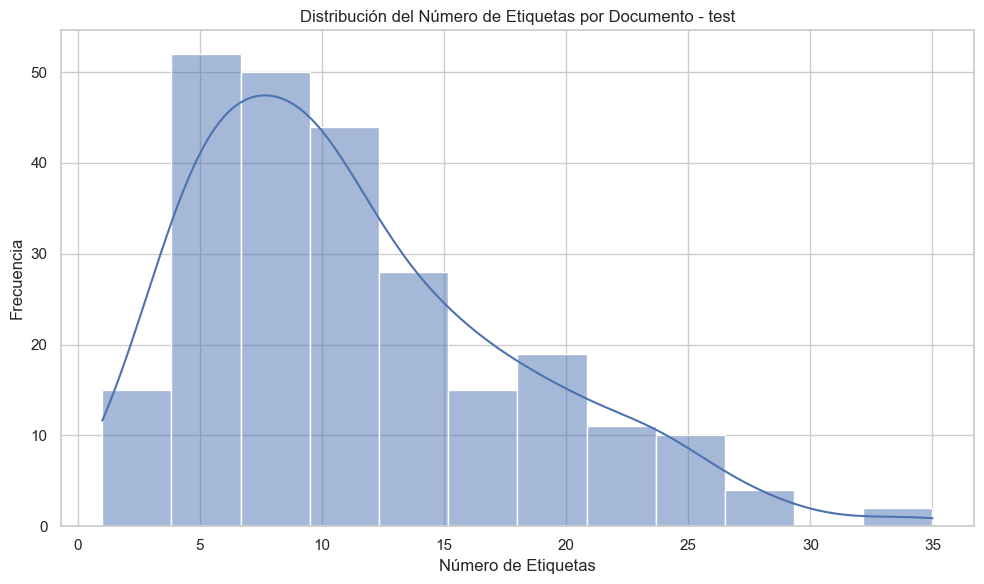


Conjunto validation:


count    250.000000
mean      10.708000
std        6.805291
min        1.000000
25%        5.000000
50%       10.000000
75%       14.000000
max       33.000000
Name: num_etiquetas_validation, dtype: float64

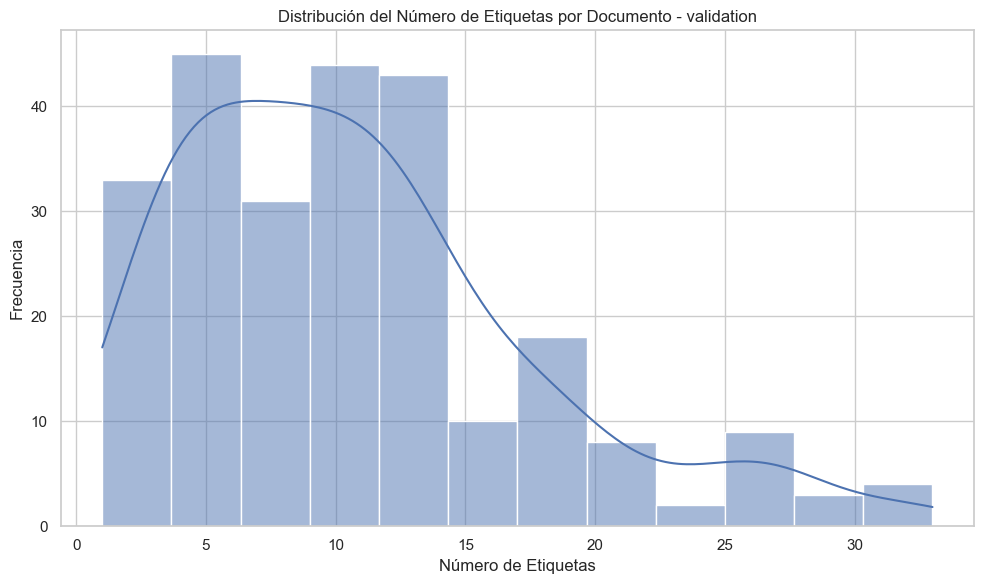

In [12]:
# Análisis estadístico descriptivo para los datasets de CODIESP
def analisis_descriptivo_codiesp():
    print("Análisis Descriptivo de Datasets CODIESP")
    print("=" * 50)

    # Estadísticas generales
    total_registros = sum(df.shape[0] for df in dfs_codiesp.values())
    print(f"Número total de registros en todos los conjuntos CODIESP: {total_registros}")

    # Información de tamaños por conjunto
    tamaños = {nombre: df.shape[0] for nombre, df in dfs_codiesp.items()}
    print("\nDistribución de registros por conjunto:")
    for nombre, tamaño in tamaños.items():
        print(f"- {nombre}: {tamaño} registros ({tamaño/total_registros*100:.1f}%)")

    # Visualización de distribución de tamaños
    plt.figure(figsize=(10, 6))
    plt.bar(tamaños.keys(), tamaños.values())
    plt.title('Distribución de Registros por Conjunto CODIESP')
    plt.xlabel('Conjunto')
    plt.ylabel('Número de Registros')
    plt.tight_layout()
    plt.show()

    # Análisis de longitud de textos
    print("\nEstadísticas de longitud de textos clínicos:")
    for nombre, df in dfs_codiesp.items():
        if 'text' in df.columns:
            df[f'longitud_texto_{nombre}'] = df['text'].str.len()
            text_stats = df[f'longitud_texto_{nombre}'].describe()
            print(f"\nConjunto {nombre}:")
            display(text_stats)

    # Visualización comparativa de longitudes de texto
    plt.figure(figsize=(12, 8))
    for nombre, df in dfs_codiesp.items():
        if f'longitud_texto_{nombre}' in df.columns:
            sns.kdeplot(df[f'longitud_texto_{nombre}'], label=nombre)

    plt.title('Comparación de Distribución de Longitudes de Texto por Conjunto')
    plt.xlabel('Longitud de Texto (caracteres)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Análisis de etiquetas por documento
    print("\nEstadísticas de número de etiquetas por documento:")
    for nombre, df in dfs_codiesp.items():
        if 'labels' in df.columns:
            # Contar etiquetas por documento
            df[f'num_etiquetas_{nombre}'] = df['labels'].apply(
                lambda x: len(eval(x)) if isinstance(x, str) else 0
            )

            labels_stats = df[f'num_etiquetas_{nombre}'].describe()
            print(f"\nConjunto {nombre}:")
            display(labels_stats)

            # Histograma
            plt.figure(figsize=(10, 6))
            sns.histplot(df[f'num_etiquetas_{nombre}'], kde=True)
            plt.title(f'Distribución del Número de Etiquetas por Documento - {nombre}')
            plt.xlabel('Número de Etiquetas')
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            plt.show()

# Ejecutar análisis descriptivo de CODIESP
analisis_descriptivo_codiesp()

## 4. Distribución de Datos por Categorías

En esta sección analizaremos la distribución de los datos por diferentes categorías y características.

Distribución de Diagnósticos por Categorías

Distribución de diagnósticos por categoría principal:

Distribución de diagnósticos por categoría principal:


categoria
A      694
B      611
C     1472
D     1014
E     1208
F     1086
G      880
H     4290
I     1778
J      452
K     1056
L     1064
M     8652
N     1021
O     3182
P      565
Q     1025
R      913
S    40323
T    15101
U        5
V     7592
W     2187
X     1028
Y     2311
Z     1736
Name: count, dtype: int64

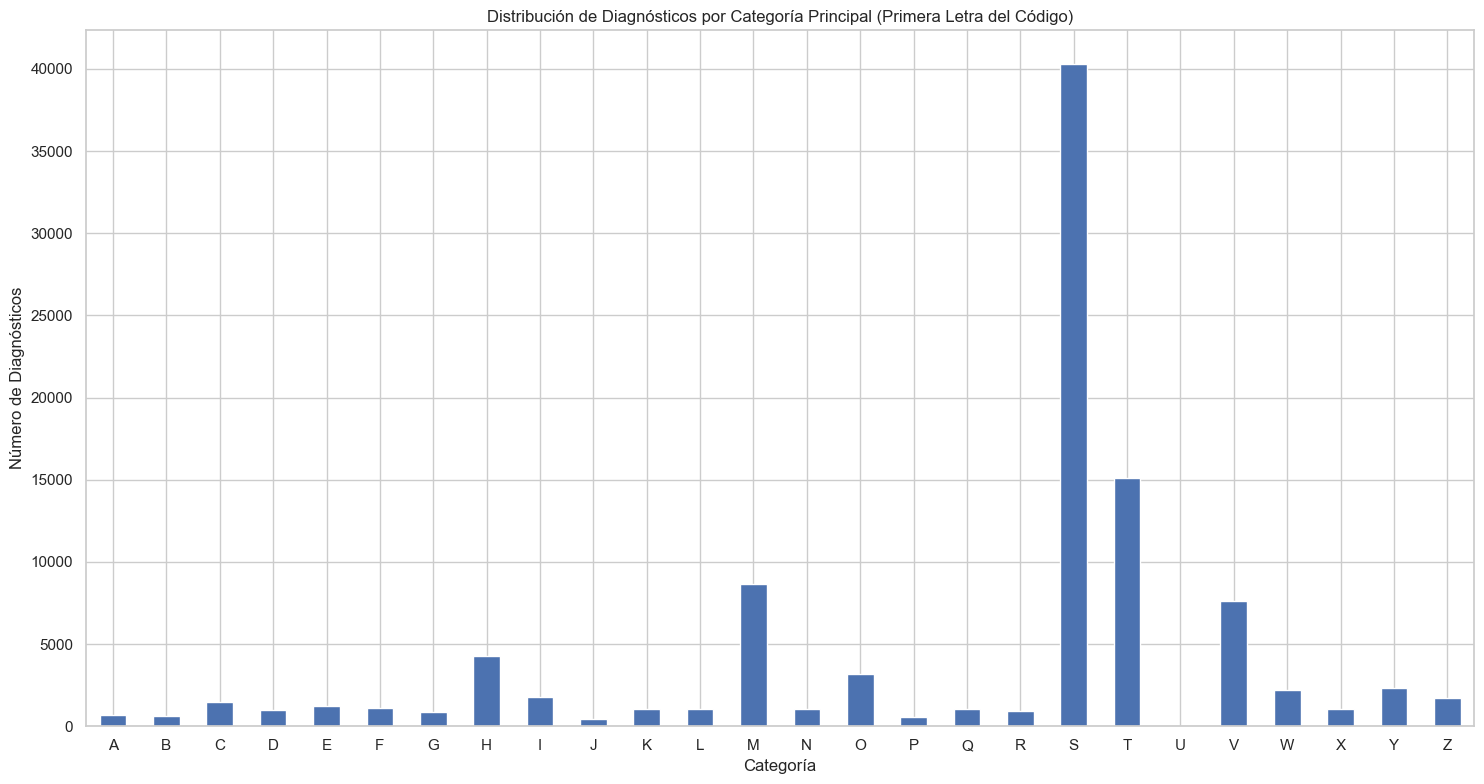


Top 20 subcategorías más comunes:


subcategoria
S6    6814
S8    5639
S5    5273
S9    4375
S7    4250
T2    3785
S3    3596
S4    3594
T4    3033
S0    2863
M8    2545
T8    2511
S2    2345
T5    1642
S1    1574
T3    1551
Y3    1442
T6    1426
V9    1412
O3    1315
Name: count, dtype: int64

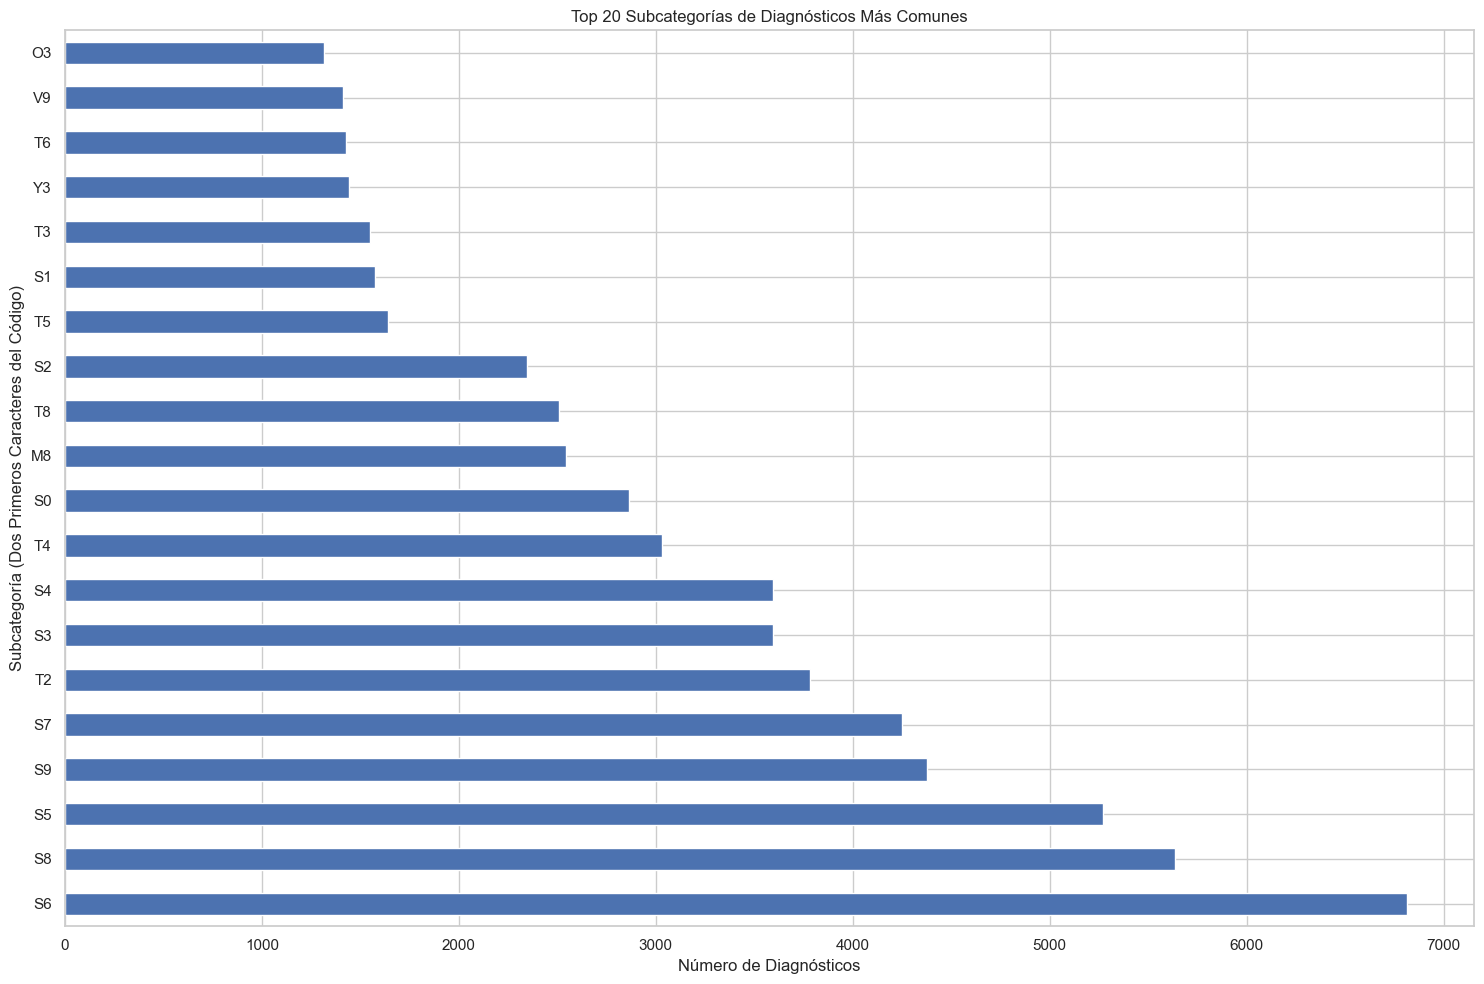


Distribución de diagnósticos por atributos específicos:

Diagnósticos con atributo 'perinatal' por categoría:


,Total_Categoría,Con_perinatal,Porcentaje
categoria,,,
A,694,1.0,0.144092
B,611,NaN,0.000000
C,1472,NaN,0.000000
D,1014,NaN,0.000000
E,1208,1.0,0.082781
F,1086,NaN,0.000000
G,880,NaN,0.000000
H,4290,4.0,0.093240
I,1778,NaN,0.000000


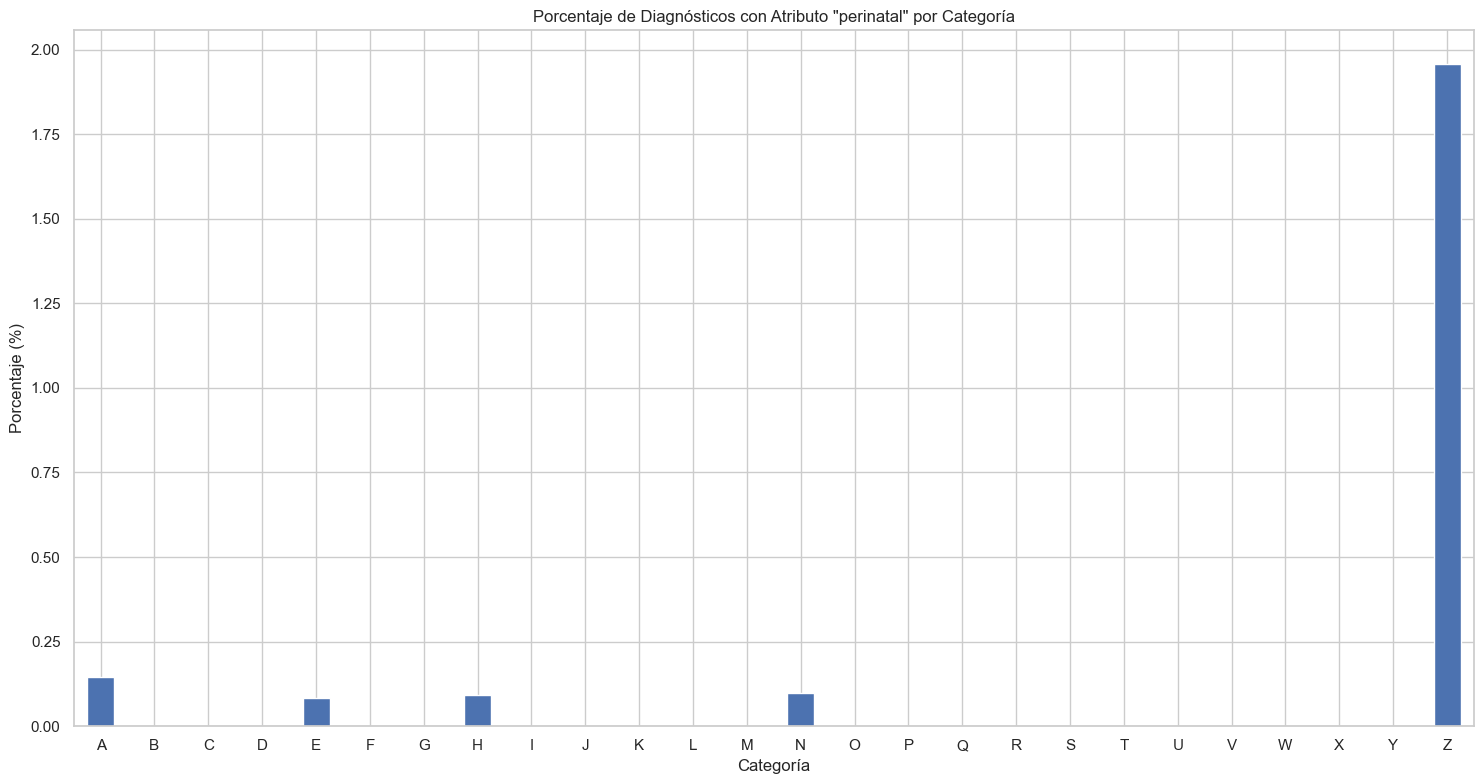


Diagnósticos con atributo 'pediatric' por categoría:


,Total_Categoría,Con_pediatric,Porcentaje
categoria,,,
A,694,1.0,0.144092
B,611,3.0,0.490998
C,1472,3.0,0.203804
D,1014,NaN,0.000000
E,1208,2.0,0.165563
F,1086,2.0,0.184162
G,880,1.0,0.113636
H,4290,25.0,0.582751
I,1778,NaN,0.000000


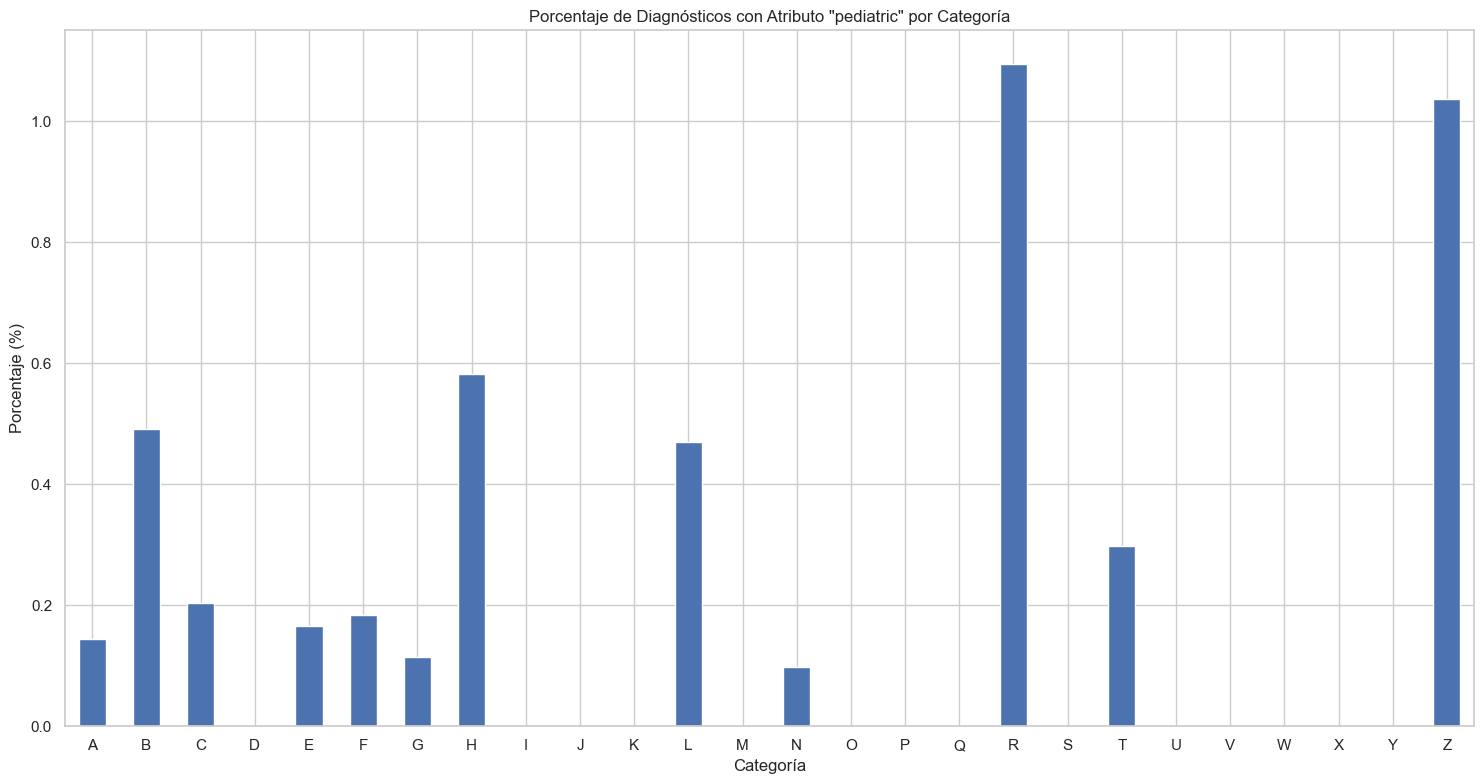


Diagnósticos con atributo 'maternity' por categoría:


,Total_Categoría,Con_maternity,Porcentaje
categoria,,,
A,694,1.0,0.144092
B,611,NaN,0.000000
C,1472,1.0,0.067935
D,1014,1.0,0.098619
E,1208,NaN,0.000000
F,1086,2.0,0.184162
G,880,NaN,0.000000
H,4290,NaN,0.000000
I,1778,NaN,0.000000


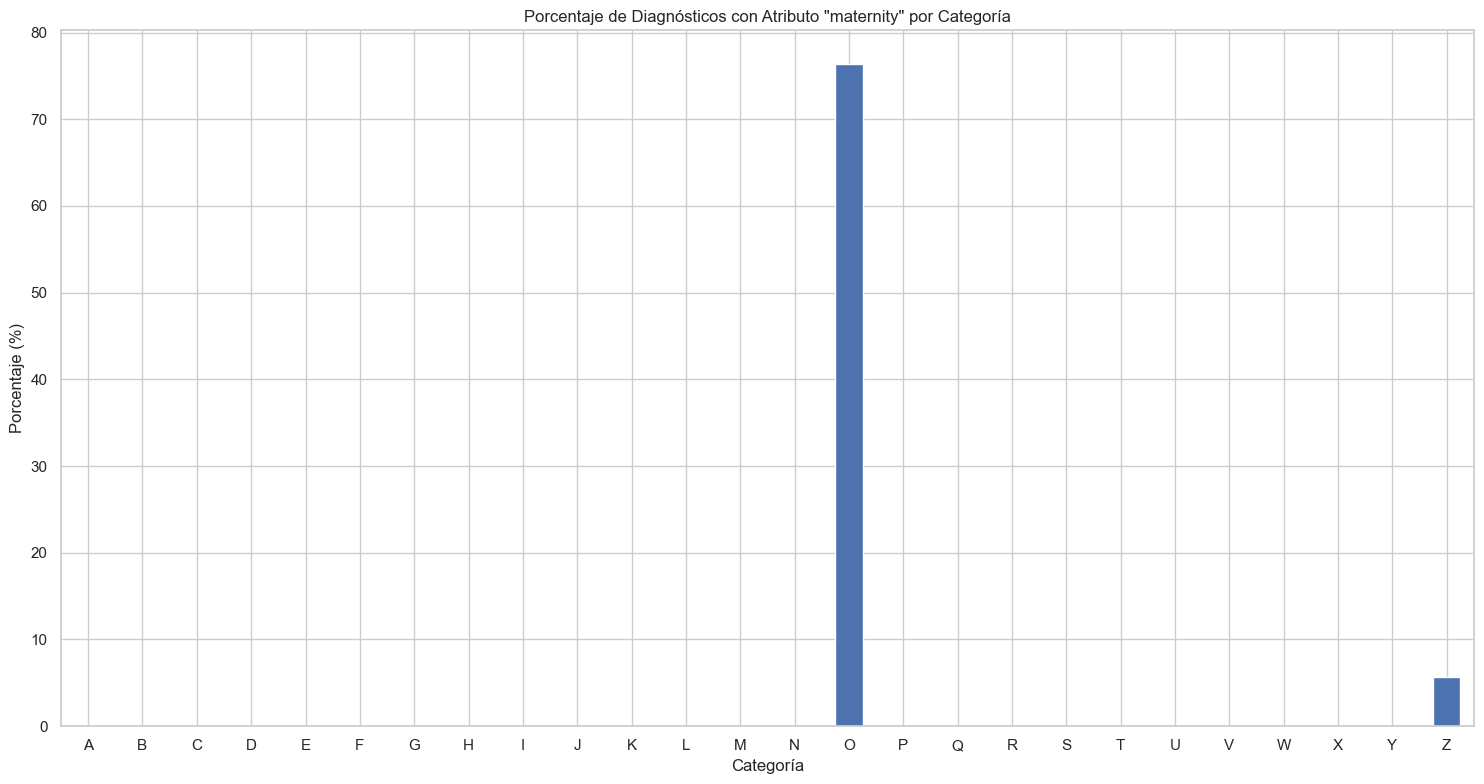


Diagnósticos con atributo 'adult' por categoría:


,Total_Categoría,Con_adult,Porcentaje
categoria,,,
A,694,1.0,0.144092
B,611,NaN,0.000000
C,1472,3.0,0.203804
D,1014,NaN,0.000000
E,1208,2.0,0.165563
F,1086,49.0,4.511971
G,880,3.0,0.340909
H,4290,93.0,2.167832
I,1778,354.0,19.910011


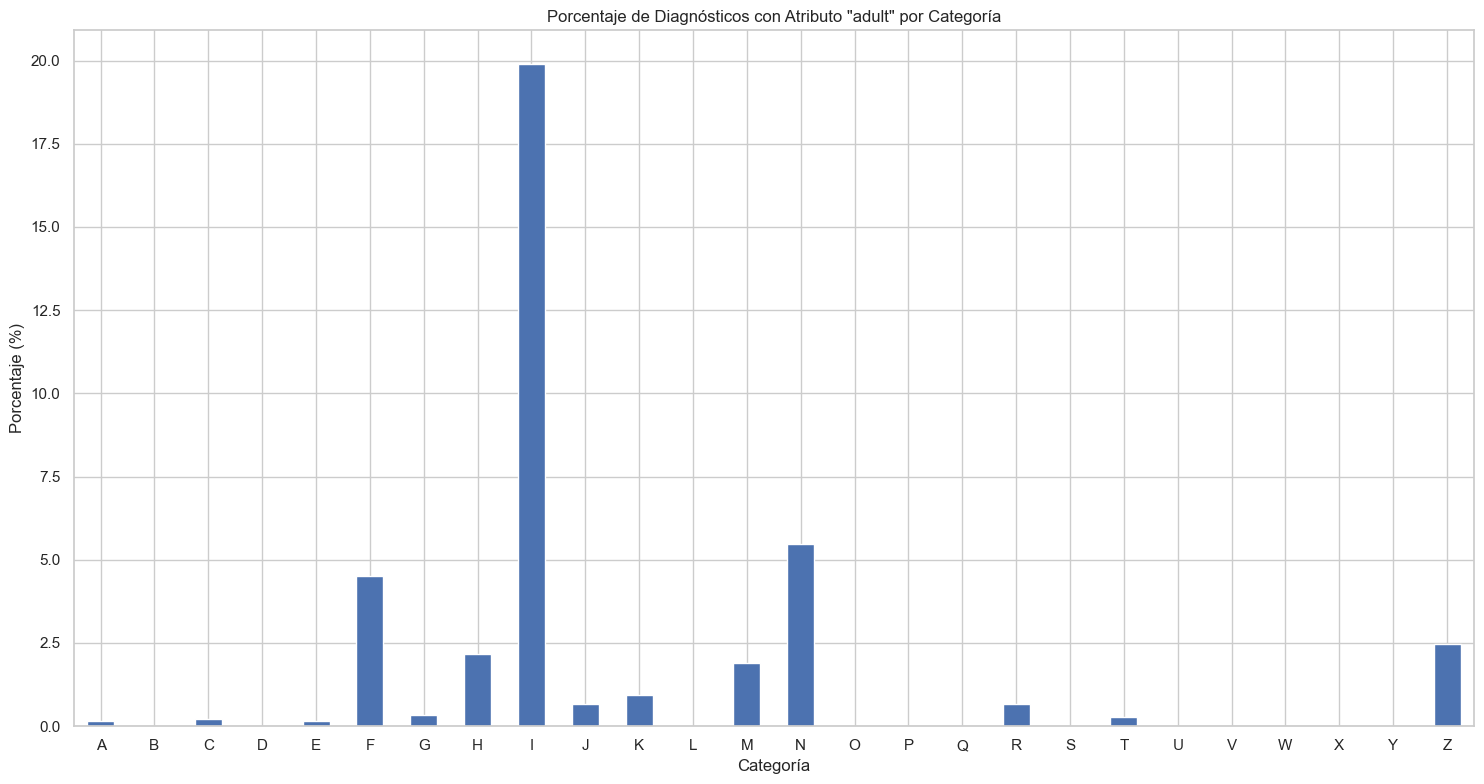

In [13]:
# Análisis de distribución de códigos de diagnóstico por categoría y subcategoría
def analisis_distribucion_diagnosticos():
    print("Distribución de Diagnósticos por Categorías")
    print("=" * 50)

    if 'code' not in df_diagnosticos.columns:
        print("La columna 'code' no existe en el dataset de diagnósticos.")
        return

    # Extraer categoría principal (primera letra del código)
    df_diagnosticos['categoria'] = df_diagnosticos['code'].str[0]

    # Extraer subcategoría (dos primeros caracteres del código)
    df_diagnosticos['subcategoria'] = df_diagnosticos['code'].str[:2]

    # Distribución por categoría principal
    cat_counts = df_diagnosticos['categoria'].value_counts().sort_index()
    print("\nDistribución de diagnósticos por categoría principal:")
    display(cat_counts)

    # Visualización por categoría
    plt.figure(figsize=(15, 8))
    cat_counts.plot(kind='bar')
    plt.title('Distribución de Diagnósticos por Categoría Principal (Primera Letra del Código)')
    plt.xlabel('Categoría')
    plt.ylabel('Número de Diagnósticos')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Top 20 subcategorías más comunes
    subcat_counts = df_diagnosticos['subcategoria'].value_counts().head(20)
    print("\nTop 20 subcategorías más comunes:")
    display(subcat_counts)

    # Visualización de top subcategorías
    plt.figure(figsize=(15, 10))
    subcat_counts.plot(kind='barh')
    plt.title('Top 20 Subcategorías de Diagnósticos Más Comunes')
    plt.xlabel('Número de Diagnósticos')
    plt.ylabel('Subcategoría (Dos Primeros Caracteres del Código)')
    plt.tight_layout()
    plt.show()

    # Análisis de diagnósticos por atributos específicos si están disponibles
    atributos_binarios = ['perinatal', 'pediatric', 'maternity', 'adult']
    atributos_presentes = [attr for attr in atributos_binarios if attr in df_diagnosticos.columns]

    if atributos_presentes:
        print("\nDistribución de diagnósticos por atributos específicos:")

        # Gráfico de distribución por categoría y atributo
        for atributo in atributos_presentes:
            # Conteo de diagnósticos con valor 1 por categoría
            diagnos_attr = df_diagnosticos[df_diagnosticos[atributo] == 1]
            if len(diagnos_attr) > 0:
                cat_attr_counts = diagnos_attr['categoria'].value_counts().sort_index()

                # Calcular porcentaje sobre el total de la categoría
                cat_total = df_diagnosticos['categoria'].value_counts().sort_index()
                cat_pct = (cat_attr_counts / cat_total * 100).fillna(0)

                print(f"\nDiagnósticos con atributo '{atributo}' por categoría:")
                display(pd.DataFrame({
                    'Total_Categoría': cat_total,
                    f'Con_{atributo}': cat_attr_counts,
                    'Porcentaje': cat_pct
                }))

                # Visualización
                plt.figure(figsize=(15, 8))
                cat_pct.plot(kind='bar')
                plt.title(f'Porcentaje de Diagnósticos con Atributo "{atributo}" por Categoría')
                plt.xlabel('Categoría')
                plt.ylabel('Porcentaje (%)')
                plt.xticks(rotation=0)
                plt.tight_layout()
                plt.show()

# Ejecutar análisis de distribución de diagnósticos
analisis_distribucion_diagnosticos()

Distribución de Procedimientos por Categorías

Distribución de procedimientos por clase:


class_name
Médico-Quirúrgica                                   68024
Imagen                                               2978
Radioterapia                                         2056
Rehabilitación Física y Audiología Diagnóstica       1380
Administración                                       1257
Colocación                                            861
Medicina Nuclear                                      463
Medición y Monitorización                             422
Obstetricia                                           304
Nueva Tecnología                                      297
Osteopatía                                            100
Quiropráctica                                          90
Otros Procedimientos                                   78
Tratamiento de Abuso de Sustancias                     59
Asistencia y Soporte Extracorpóreos o Sistémicos       51
Terapias Extracorpóreas o Sistémicas                   46
Salud Mental                                           30
Nam

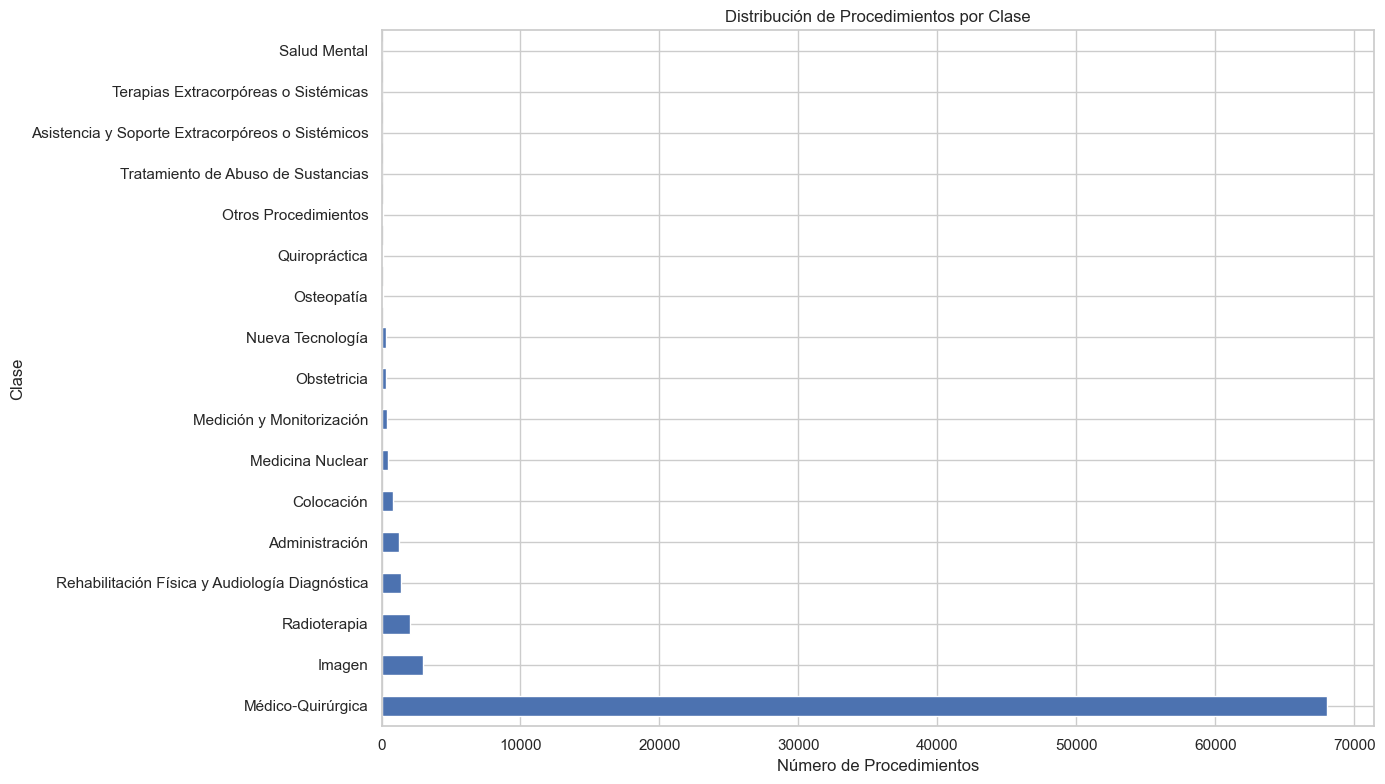


Distribución por subclase para las top 5 clases:

Top 10 subclases para la clase 'Médico-Quirúrgica':


subclass_name
Arterias Inferiores          4961
Sistema Gastrointestinal     4569
Articulaciones Superiores    4087
Arterias Superiores          3830
Articulaciones Inferiores    3383
Corazón y Grandes Vasos      3071
Huesos Superiores            2907
Huesos Inferiores            2898
Venas Superiores             2486
Venas Inferiores             2347
Name: count, dtype: int64

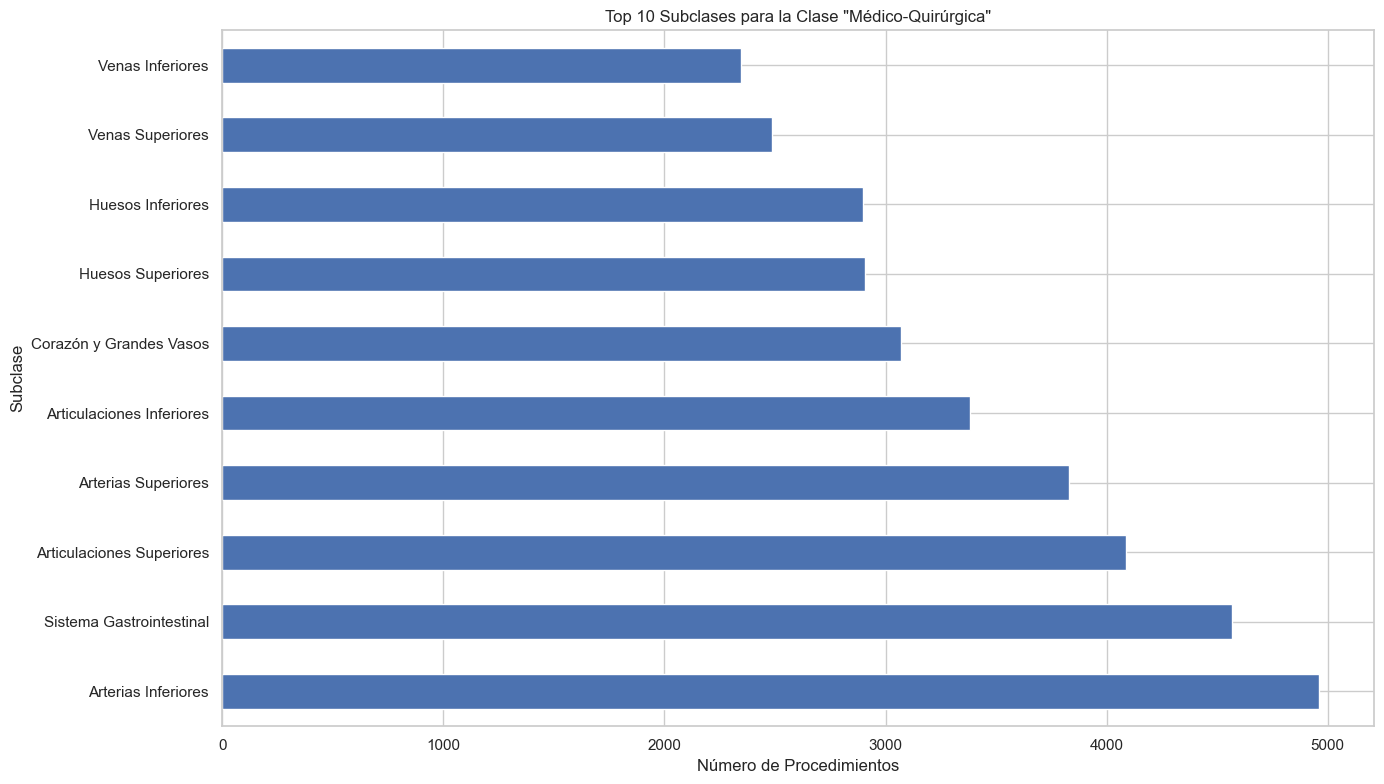


Top 10 subclases para la clase 'Imagen':


subclass_name
Venas                                                   508
Arterias Superiores                                     390
Huesos Superiores no Axiales                            275
Arterias Inferiores                                     248
Huesos Inferiores no Axiales                            244
Esqueleto Axial, Excepto Huesos Craneales y Faciales    157
Sistema Urinario                                        156
Corazón                                                 137
Regiones Anatómicas                                     109
Oído, Nariz, Boca y Garganta                            104
Name: count, dtype: int64

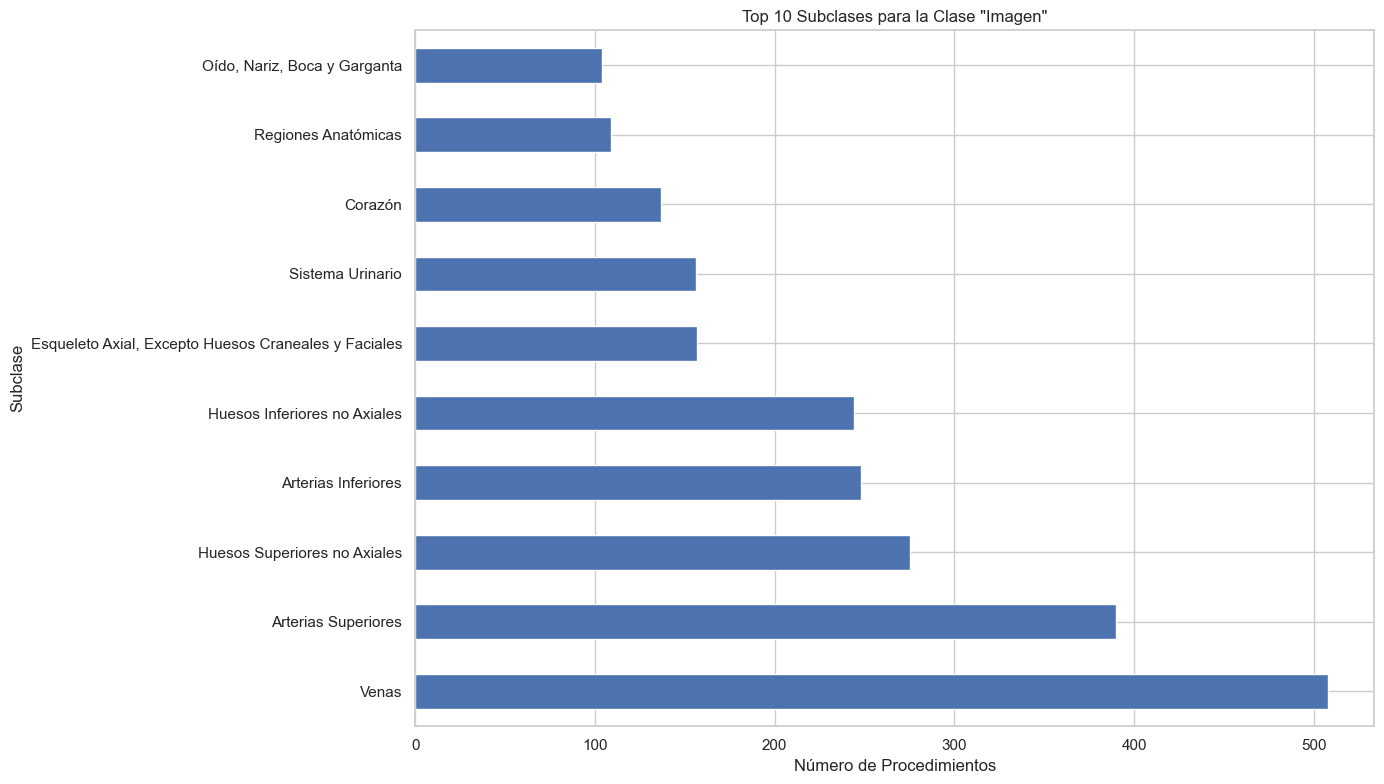


Top 10 subclases para la clase 'Radioterapia':


subclass_name
Oído, Nariz, Boca y Garganta             336
Sistema Linfático y Hemático             243
Sistema Gastrointestinal                 204
Sistema Respiratorio                     196
Regiones Anatómicas                      155
Sistema Endocrino                        135
Sistema Músculo Esquelético              121
Sistema Nervioso Central y Periférico    116
Sistema Hepatobiliar y Páncreas          116
Sistema Urinario                         116
Name: count, dtype: int64

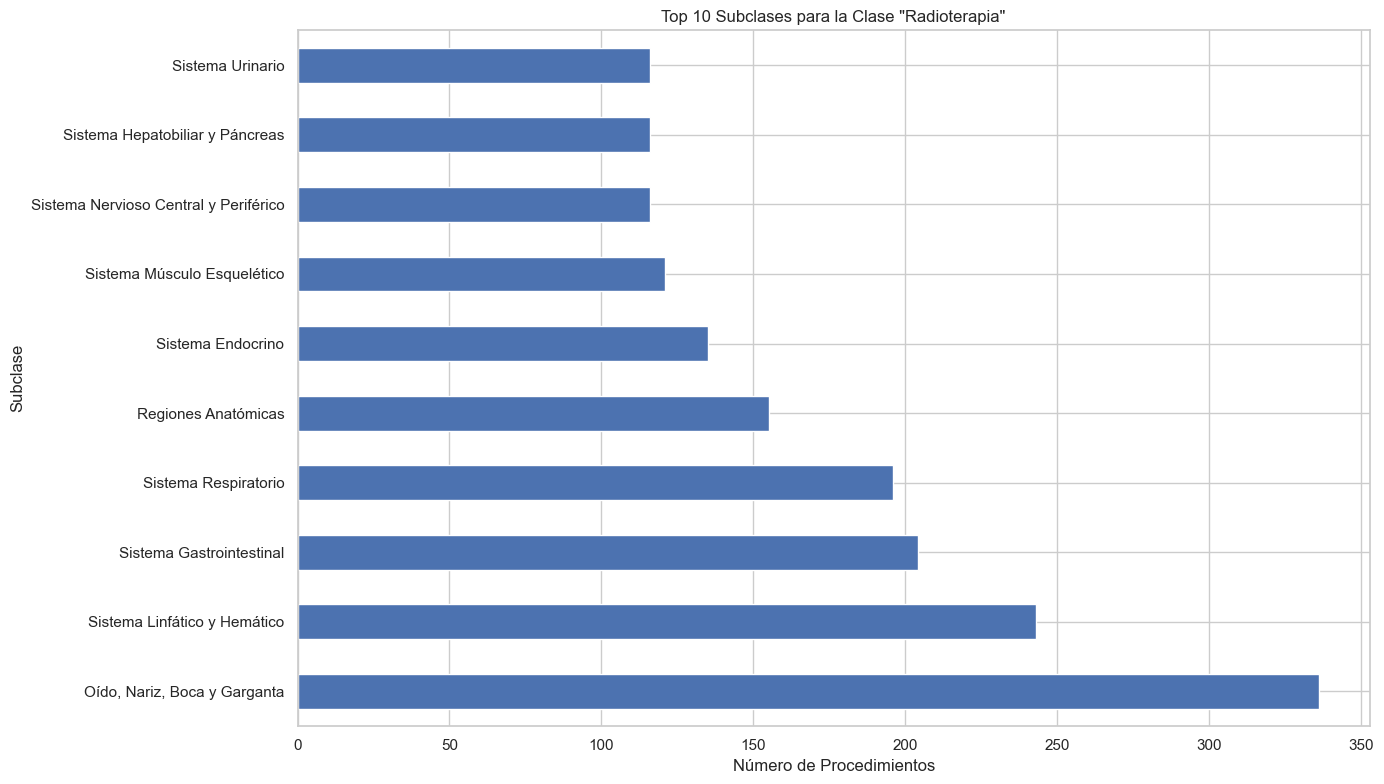


Top 10 subclases para la clase 'Rehabilitación Física y Audiología Diagnóstica':


subclass_name
Rehabilitación            1232
Audiología Diagnóstica     148
Name: count, dtype: int64

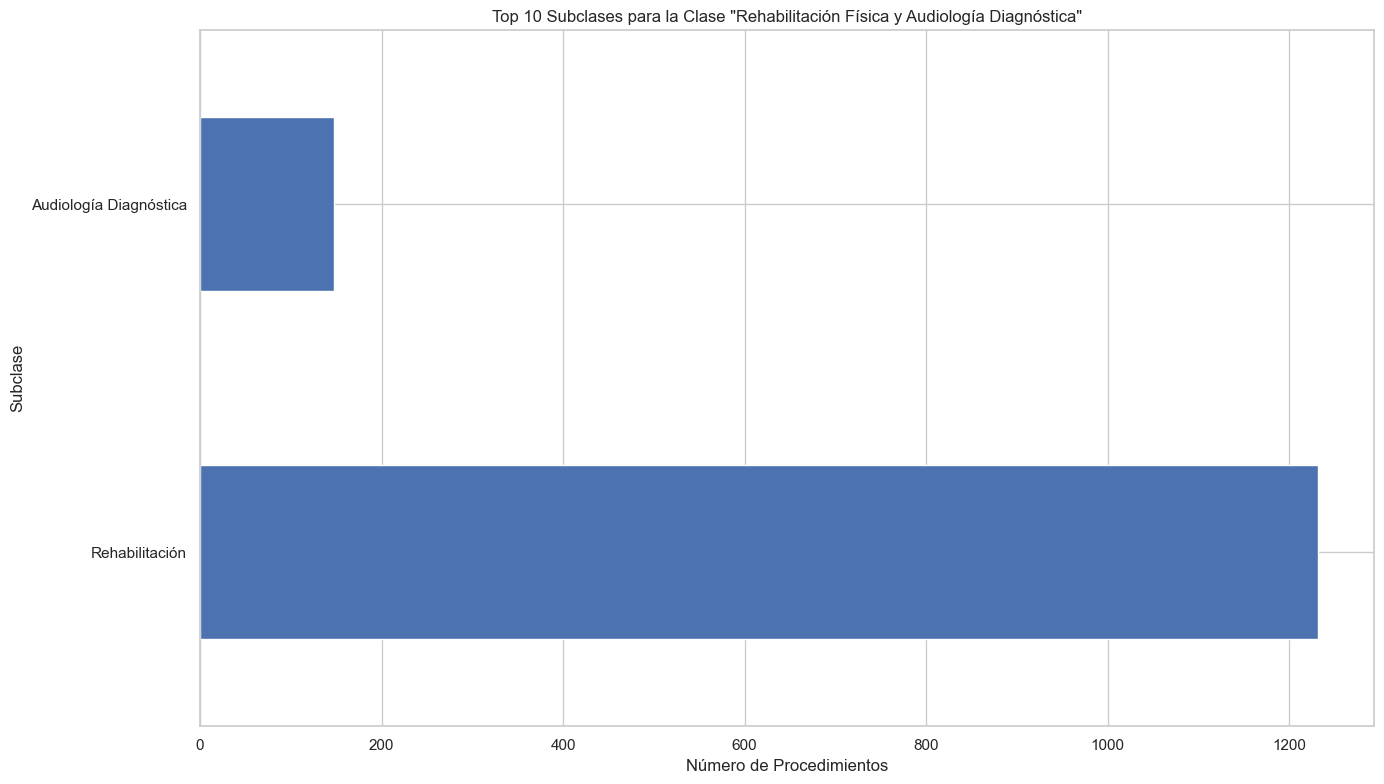


Top 10 subclases para la clase 'Administración':


subclass_name
Sistemas Fisiológicos y Regiones Anatómicas    1141
Circulatorio                                    115
Dispositivo Permanente                            1
Name: count, dtype: int64

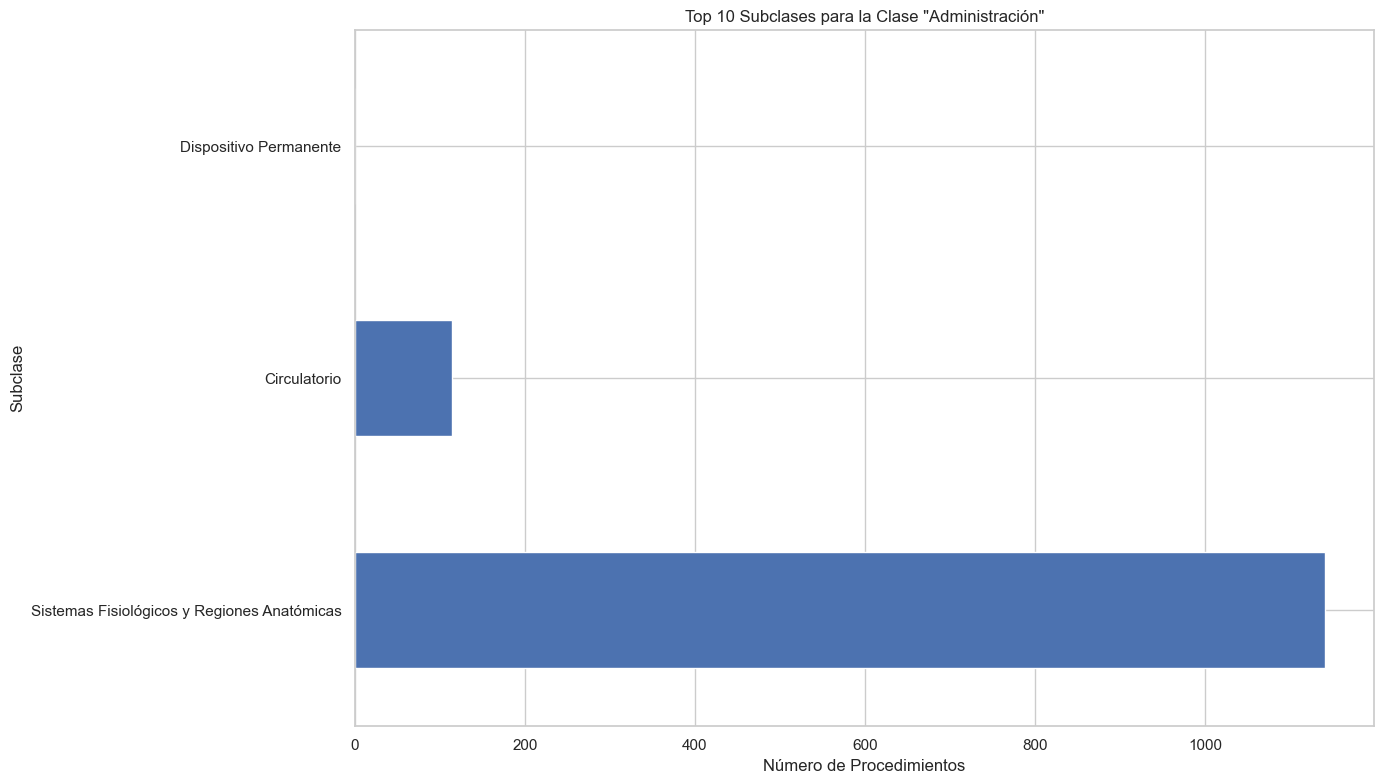


Top 15 tipos de procedimientos más comunes:


procedure
Drenaje        6864
Derivación     5817
Revisión       5778
Retirada       5547
Suplemento     5365
Escisión       4609
Inserción      4076
Sustitución    3580
Dilatación     3430
Reparación     2758
Destrucción    2405
Reposición     2320
Liberación     2299
Extirpación    2261
Oclusión       2131
Name: count, dtype: int64

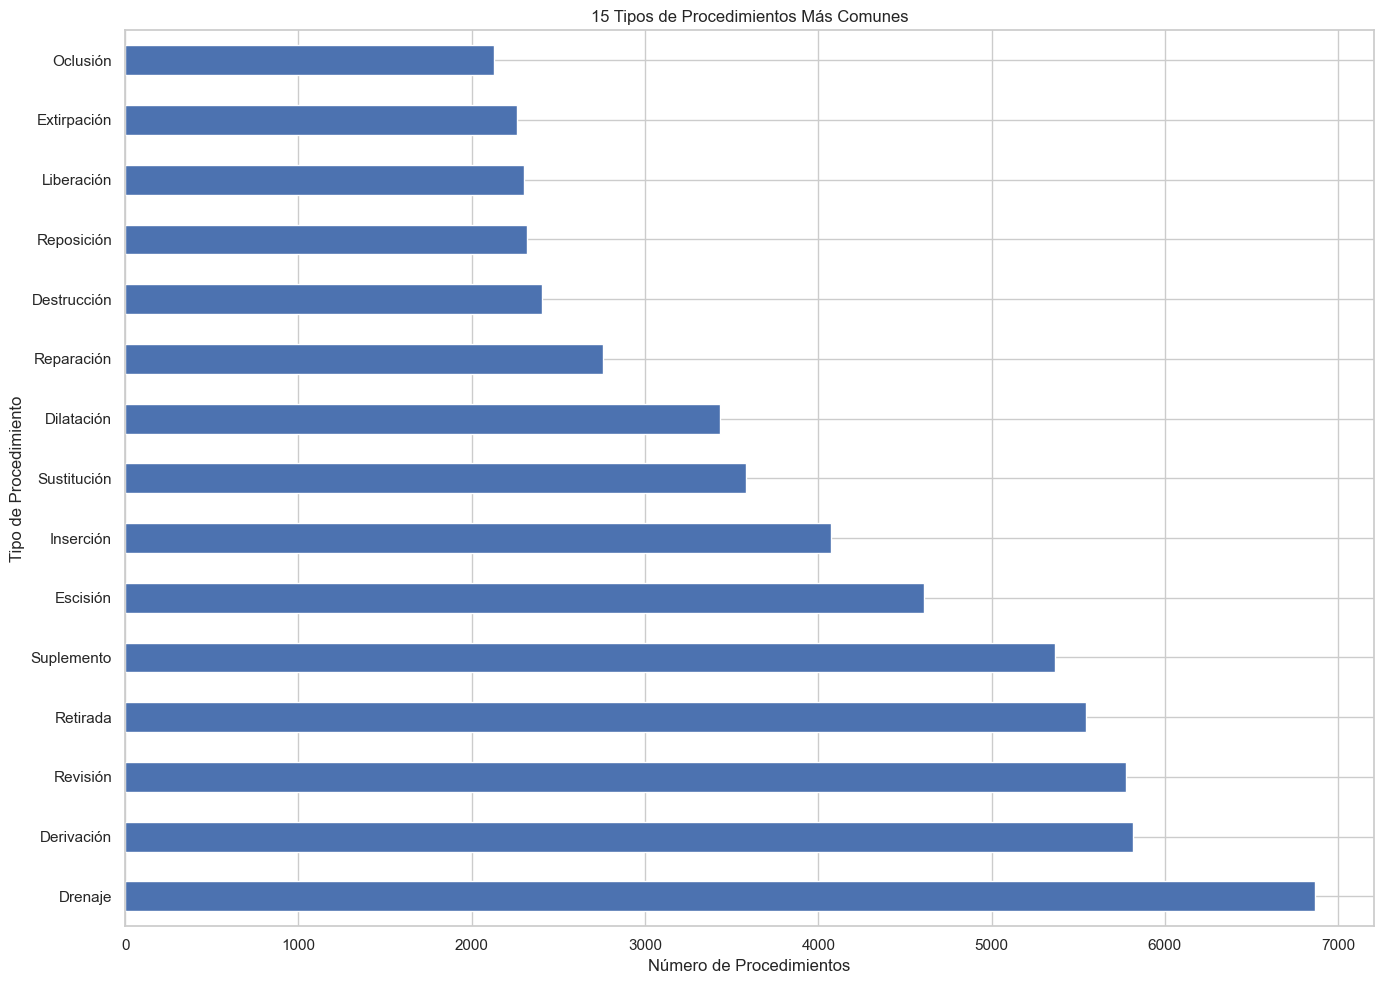


Distribución de procedimientos por tipo de abordaje:


approach
Abierto                                             22916
Endoscópico Percutáneo                              19284
Percutáneo                                          17261
Externo                                              5599
Orificio Natural o Artificial, Endoscópico           3565
                                                    ...  
Samario 153 (Sm-153)                                    1
Carbono 11 (C-11)                                       1
Intermitente, Menos de 6 Horas al Día                   1
Otro Procesamiento Auditivo Central Especificado        1
Estroncio 89 (Sr-89)                                    1
Name: count, Length: 190, dtype: int64

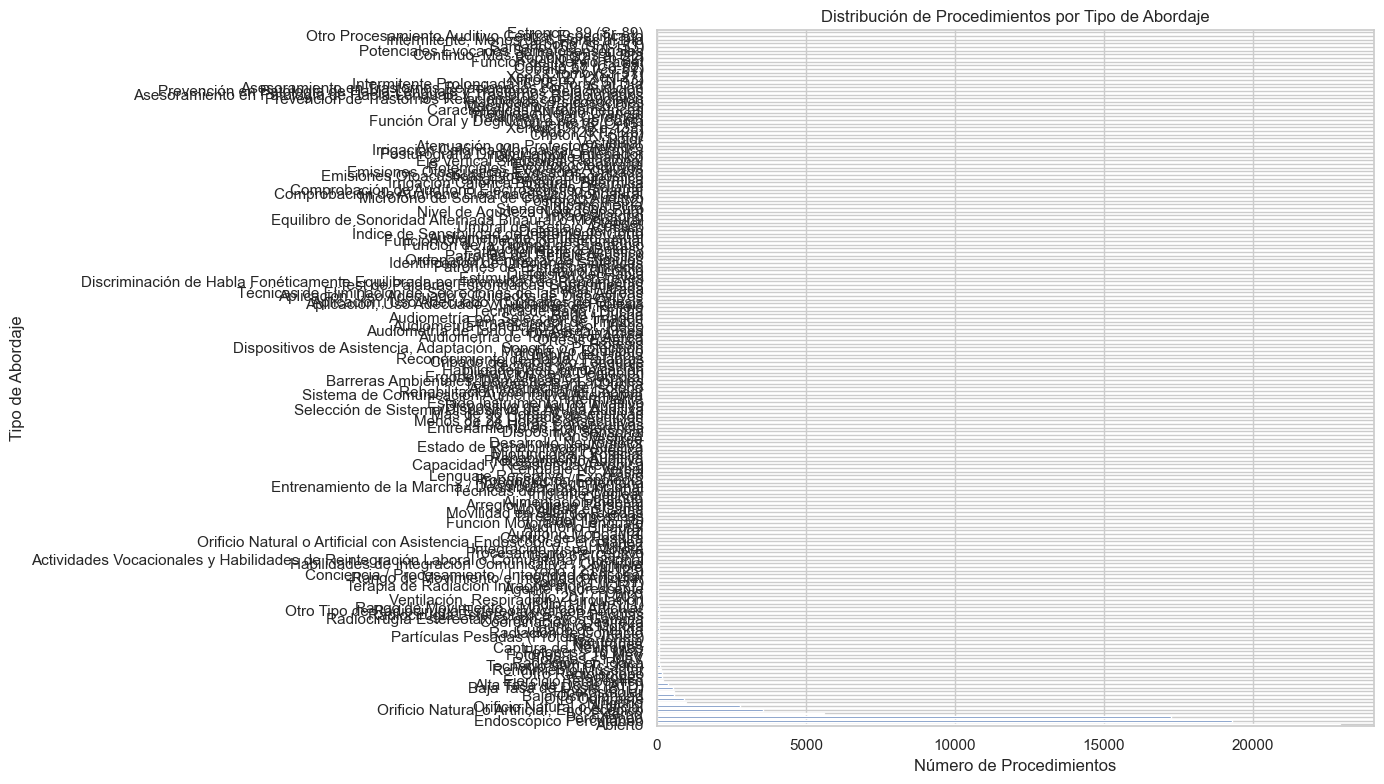


Análisis cruzado de tipos de procedimientos vs tipos de abordaje:


approach,Abierto,Endoscópico Percutáneo,Externo,Orificio Natural o Artificial,"Orificio Natural o Artificial, Endoscópico",Percutáneo
procedure,,,,,,
Derivación,3004,2314,0,0,344,155
Drenaje,2040,1824,210,336,417,2037
Retirada,1384,1257,979,281,279,1367
Revisión,1374,1251,1244,282,282,1345
Suplemento,1947,1694,90,186,306,1142


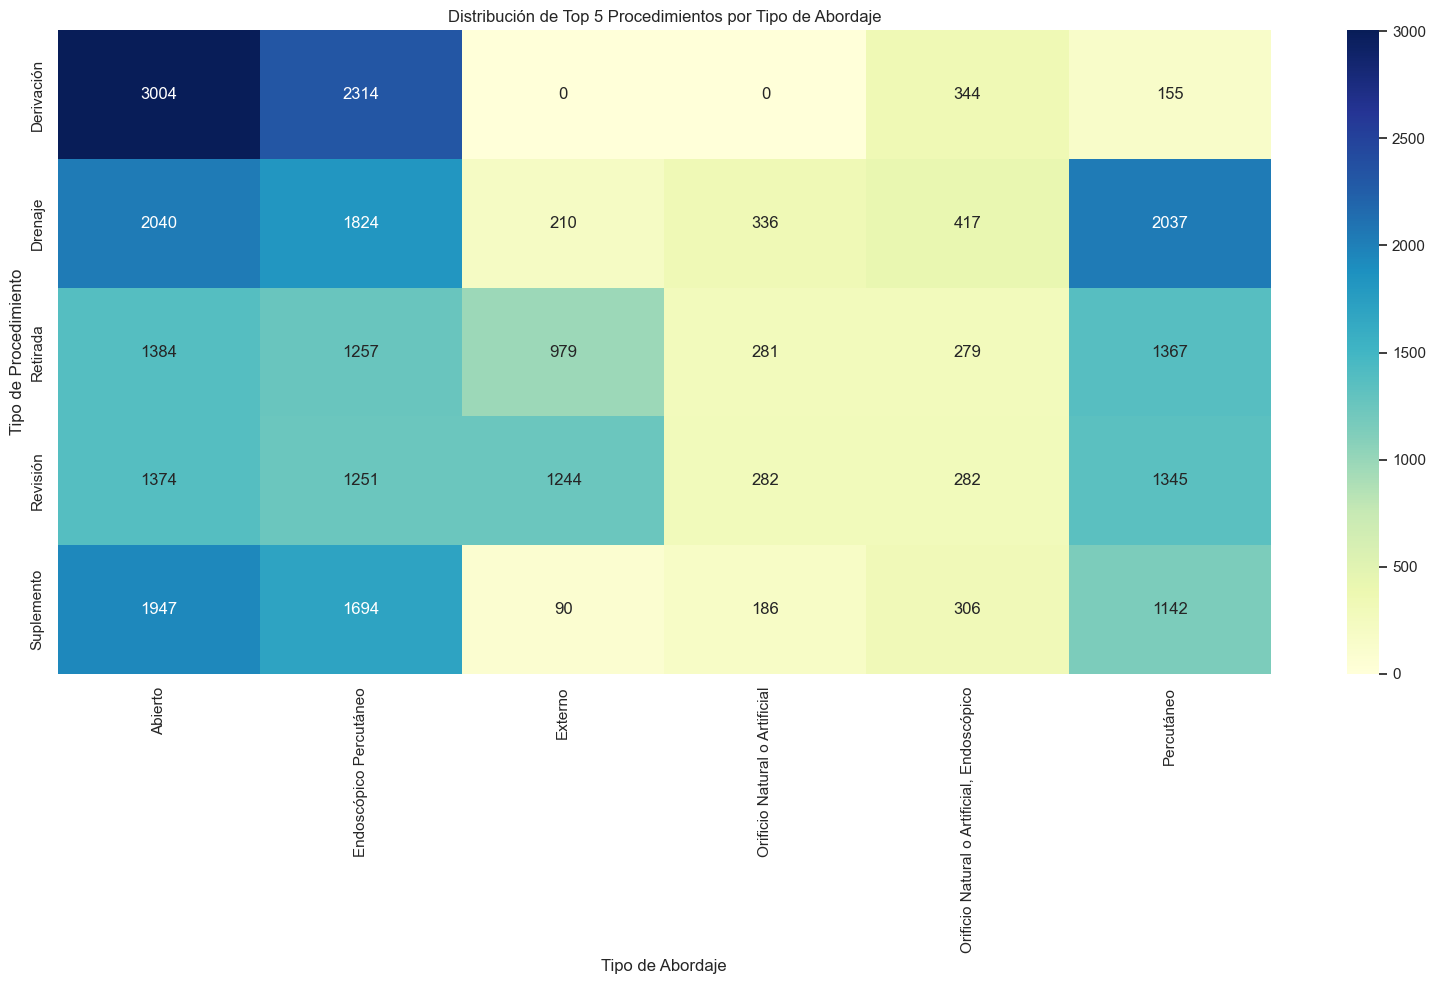

In [14]:
# Análisis de distribución de procedimientos por categorías y subcategorías
def analisis_distribucion_procedimientos():
    print("Distribución de Procedimientos por Categorías")
    print("=" * 50)

    # Análisis por clase y subclase
    if 'class_name' in df_procedimientos.columns and 'subclass_name' in df_procedimientos.columns:
        # Distribución por clase
        class_counts = df_procedimientos['class_name'].value_counts()
        print("\nDistribución de procedimientos por clase:")
        display(class_counts)

        # Visualización por clase
        plt.figure(figsize=(14, 8))
        class_counts.plot(kind='barh')
        plt.title('Distribución de Procedimientos por Clase')
        plt.xlabel('Número de Procedimientos')
        plt.ylabel('Clase')
        plt.tight_layout()
        plt.show()

        # Distribución por subclase para las top 5 clases
        top_classes = class_counts.head(5).index
        print("\nDistribución por subclase para las top 5 clases:")

        for i, clase in enumerate(top_classes):
            subclass_counts = df_procedimientos[df_procedimientos['class_name'] == clase]['subclass_name'].value_counts().head(10)
            print(f"\nTop 10 subclases para la clase '{clase}':")
            display(subclass_counts)

            # Visualización por subclase
            plt.figure(figsize=(14, 8))
            subclass_counts.plot(kind='barh')
            plt.title(f'Top 10 Subclases para la Clase "{clase}"')
            plt.xlabel('Número de Procedimientos')
            plt.ylabel('Subclase')
            plt.tight_layout()
            plt.show()

    # Análisis por tipo de procedimiento
    if 'procedure' in df_procedimientos.columns:
        proc_counts = df_procedimientos['procedure'].value_counts().head(15)
        print("\nTop 15 tipos de procedimientos más comunes:")
        display(proc_counts)

        # Visualización
        plt.figure(figsize=(14, 10))
        proc_counts.plot(kind='barh')
        plt.title('15 Tipos de Procedimientos Más Comunes')
        plt.xlabel('Número de Procedimientos')
        plt.ylabel('Tipo de Procedimiento')
        plt.tight_layout()
        plt.show()

    # Análisis por enfoque (approach)
    if 'approach' in df_procedimientos.columns:
        approach_counts = df_procedimientos['approach'].value_counts()
        print("\nDistribución de procedimientos por tipo de abordaje:")
        display(approach_counts)

        # Visualización
        plt.figure(figsize=(14, 8))
        approach_counts.plot(kind='barh')
        plt.title('Distribución de Procedimientos por Tipo de Abordaje')
        plt.xlabel('Número de Procedimientos')
        plt.ylabel('Tipo de Abordaje')
        plt.tight_layout()
        plt.show()

    # Análisis cruzado: procedimiento vs abordaje
    if 'procedure' in df_procedimientos.columns and 'approach' in df_procedimientos.columns:
        print("\nAnálisis cruzado de tipos de procedimientos vs tipos de abordaje:")

        # Top 5 procedimientos
        top_procs = df_procedimientos['procedure'].value_counts().head(5).index

        # Crear una tabla cruzada
        cross_tab = pd.crosstab(
            df_procedimientos[df_procedimientos['procedure'].isin(top_procs)]['procedure'],
            df_procedimientos[df_procedimientos['procedure'].isin(top_procs)]['approach']
        )

        display(cross_tab)

        # Visualización con mapa de calor
        plt.figure(figsize=(16, 10))
        sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='d')
        plt.title('Distribución de Top 5 Procedimientos por Tipo de Abordaje')
        plt.xlabel('Tipo de Abordaje')
        plt.ylabel('Tipo de Procedimiento')
        plt.tight_layout()
        plt.show()

# Ejecutar análisis de distribución de procedimientos
analisis_distribucion_procedimientos()

## 5. Visualización de Datos

En esta sección, crearemos visualizaciones adicionales para entender mejor los datos y sus relaciones.

Visualizaciones Avanzadas de los Datos

Visualizando jerarquía de categorías de diagnósticos (Treemap):



Visualizando comparación de tamaños de los datasets:


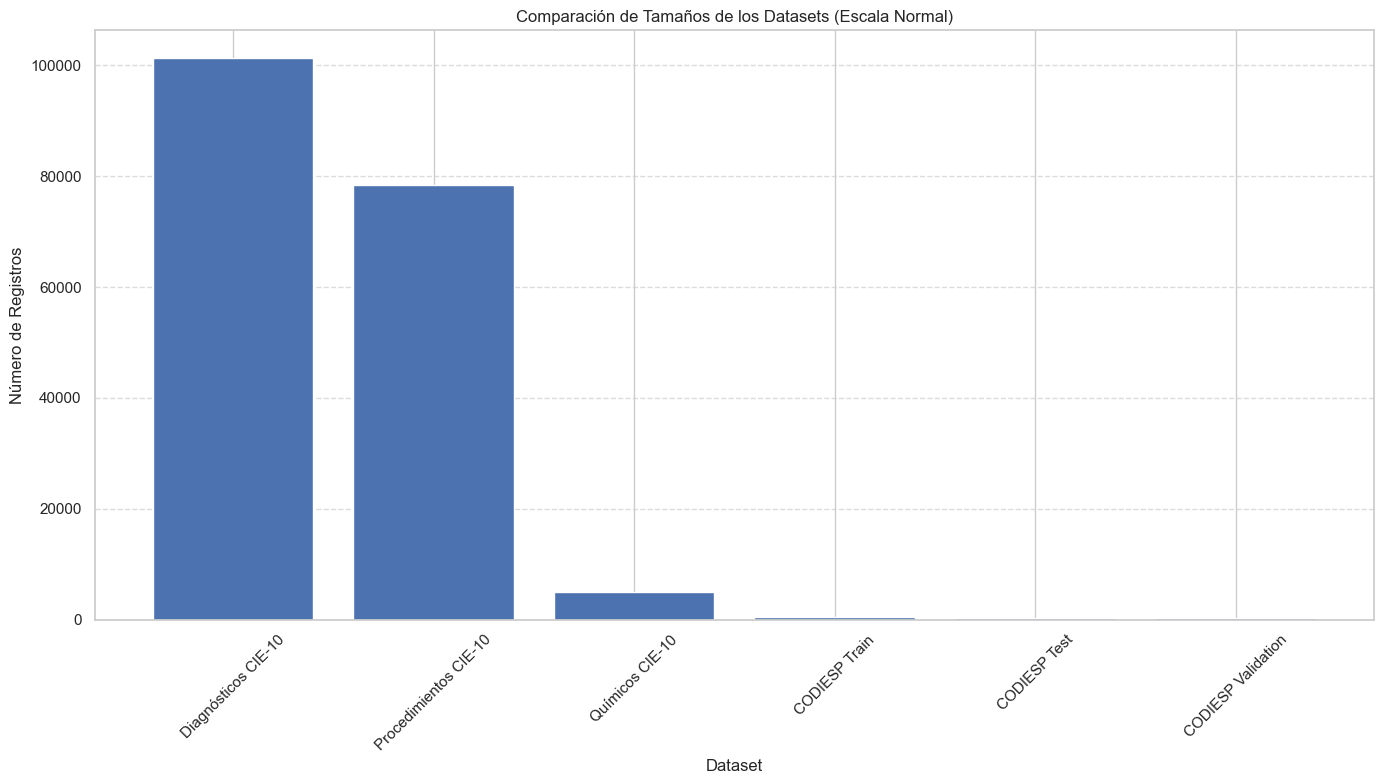

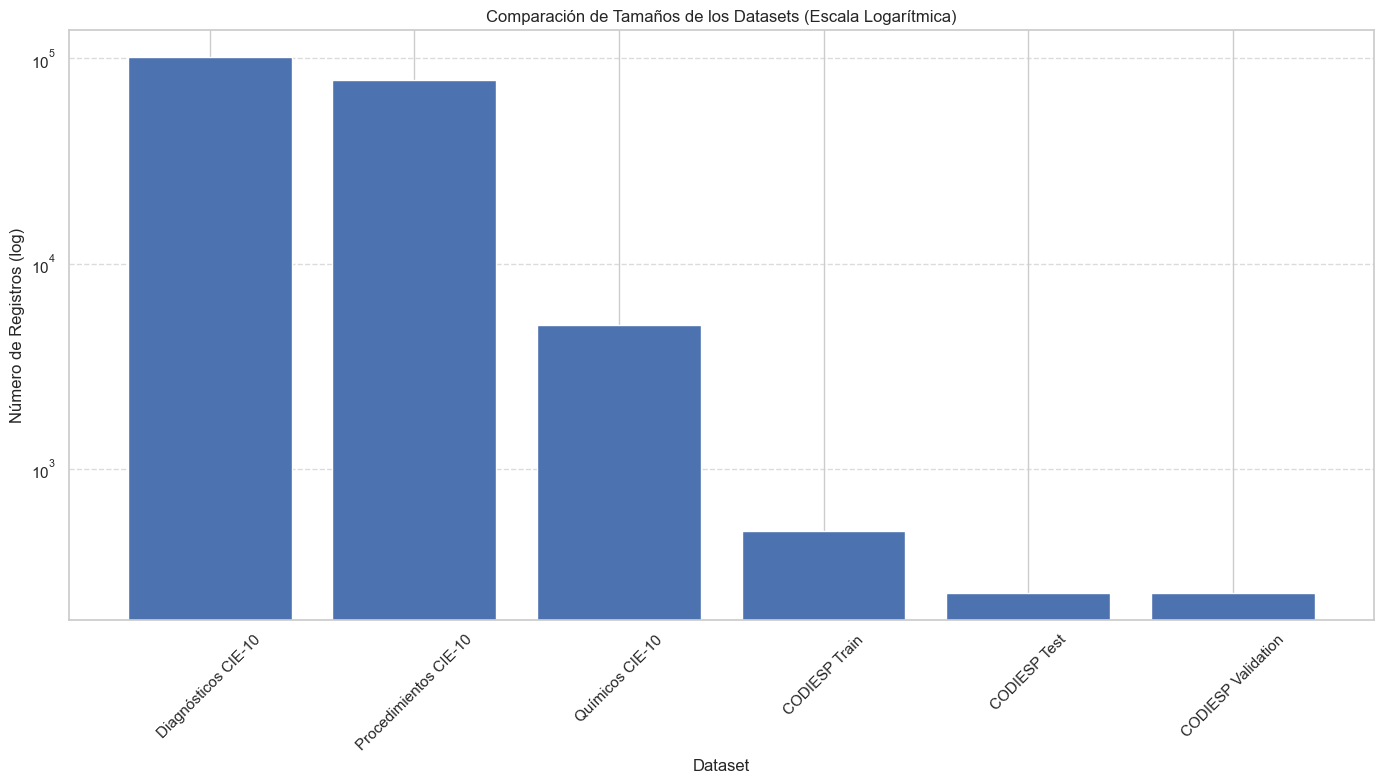


Visualizando distribución de longitudes de texto y descripciones:


/Users/david/own/CIE-10/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning:

divide by zero encountered in vecdot

/Users/david/own/CIE-10/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning:

overflow encountered in vecdot

/Users/david/own/CIE-10/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning:

invalid value encountered in vecdot

/Users/david/own/CIE-10/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning:

divide by zero encountered in vecdot

/Users/david/own/CIE-10/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning:

overflow encountered in vecdot

/Users/david/own/CIE-10/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning:

invalid value encountered in vecdot

/Users/david/own/CIE-10/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning:

divide by zero encountered in vecdot

/Users/david/own/CIE-10/.venv/lib/

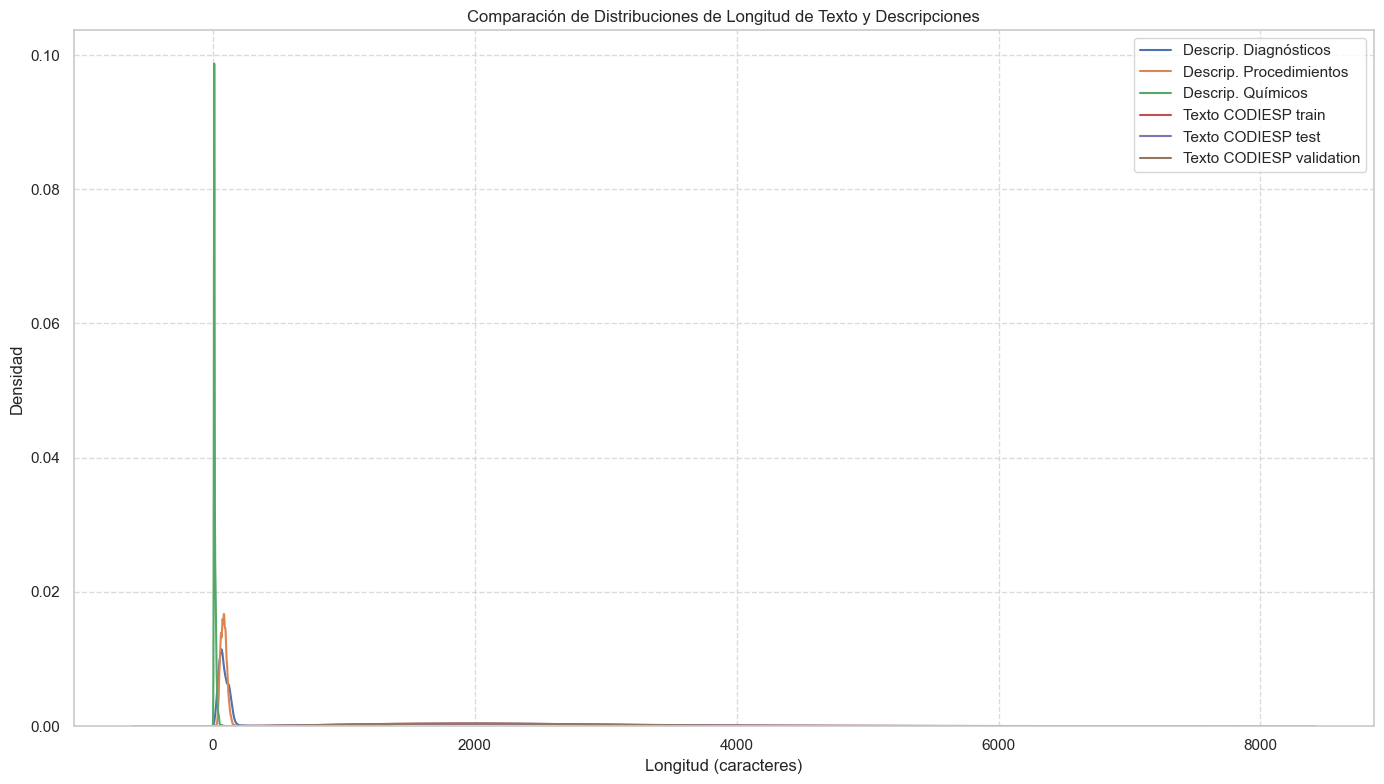

In [15]:
# Crear visualizaciones más avanzadas
def crear_visualizaciones_avanzadas():
    print("Visualizaciones Avanzadas de los Datos")
    print("=" * 50)

    # 1. Visualización de la jerarquía de categorías de diagnósticos
    if 'code' in df_diagnosticos.columns:
        # Extraer categoría y subcategoría
        df_diagnosticos['categoria'] = df_diagnosticos['code'].str[0]
        df_diagnosticos['subcategoria'] = df_diagnosticos['code'].str[:2]

        # Preparar datos para treemap
        cat_counts = df_diagnosticos['categoria'].value_counts().reset_index()
        cat_counts.columns = ['categoria', 'conteo']

        subcat_counts = df_diagnosticos.groupby(['categoria', 'subcategoria']).size().reset_index()
        subcat_counts.columns = ['categoria', 'subcategoria', 'conteo']

        print("\nVisualizando jerarquía de categorías de diagnósticos (Treemap):")

        # Crear el treemap usando plotly
        fig = px.treemap(
            subcat_counts,
            path=['categoria', 'subcategoria'],
            values='conteo',
            title='Jerarquía de Categorías y Subcategorías de Diagnósticos CIE-10-ES'
        )
        fig.update_layout(width=1000, height=700)
        fig.show()

    # 2. Visualización comparativa de tamaños de datasets
    print("\nVisualizando comparación de tamaños de los datasets:")

    sizes = {
        'Diagnósticos CIE-10': df_diagnosticos.shape[0],
        'Procedimientos CIE-10': df_procedimientos.shape[0],
        'Químicos CIE-10': df_quimicos.shape[0],
        'CODIESP Train': dfs_codiesp.get('train', pd.DataFrame()).shape[0],
        'CODIESP Test': dfs_codiesp.get('test', pd.DataFrame()).shape[0],
        'CODIESP Validation': dfs_codiesp.get('validation', pd.DataFrame()).shape[0]
    }

    # Crear el gráfico de barras
    plt.figure(figsize=(14, 8))
    plt.bar(sizes.keys(), sizes.values())
    plt.title('Comparación de Tamaños de los Datasets (Escala Normal)')
    plt.xlabel('Dataset')
    plt.ylabel('Número de Registros')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Escala logarítmica para mejor visualización de las diferencias
    plt.figure(figsize=(14, 8))
    plt.bar(sizes.keys(), sizes.values())
    plt.yscale('log')
    plt.title('Comparación de Tamaños de los Datasets (Escala Logarítmica)')
    plt.xlabel('Dataset')
    plt.ylabel('Número de Registros (log)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 3. Visualización de la distribución de longitudes de texto/descripciones
    print("\nVisualizando distribución de longitudes de texto y descripciones:")

    longitudes = {}

    # Longitudes de descripción en datasets CIE-10
    if 'description' in df_diagnosticos.columns:
        longitudes['Descrip. Diagnósticos'] = df_diagnosticos['description'].str.len()

    if 'description' in df_procedimientos.columns:
        longitudes['Descrip. Procedimientos'] = df_procedimientos['description'].str.len()

    if 'description' in df_quimicos.columns:
        longitudes['Descrip. Químicos'] = df_quimicos['description'].str.len()

    # Longitudes de texto en CODIESP
    for nombre, df in dfs_codiesp.items():
        if 'text' in df.columns:
            longitudes[f'Texto CODIESP {nombre}'] = df['text'].str.len()

    # Crear visualización comparativa de densidades
    plt.figure(figsize=(14, 8))
    for nombre, valores in longitudes.items():
        if len(valores) > 0:
            sns.kdeplot(valores, label=nombre)

    plt.title('Comparación de Distribuciones de Longitud de Texto y Descripciones')
    plt.xlabel('Longitud (caracteres)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Ejecutar función de visualizaciones avanzadas
crear_visualizaciones_avanzadas()

## 6. Análisis Comparativo entre Ficheros

En esta sección, compararemos los diferentes archivos para identificar relaciones y patrones comunes.

Análisis Comparativo entre Ficheros

Comparación entre categorías de diagnósticos y tipos de productos químicos:
Se encontraron 1 categorías comunes entre diagnósticos y químicos:
['T']


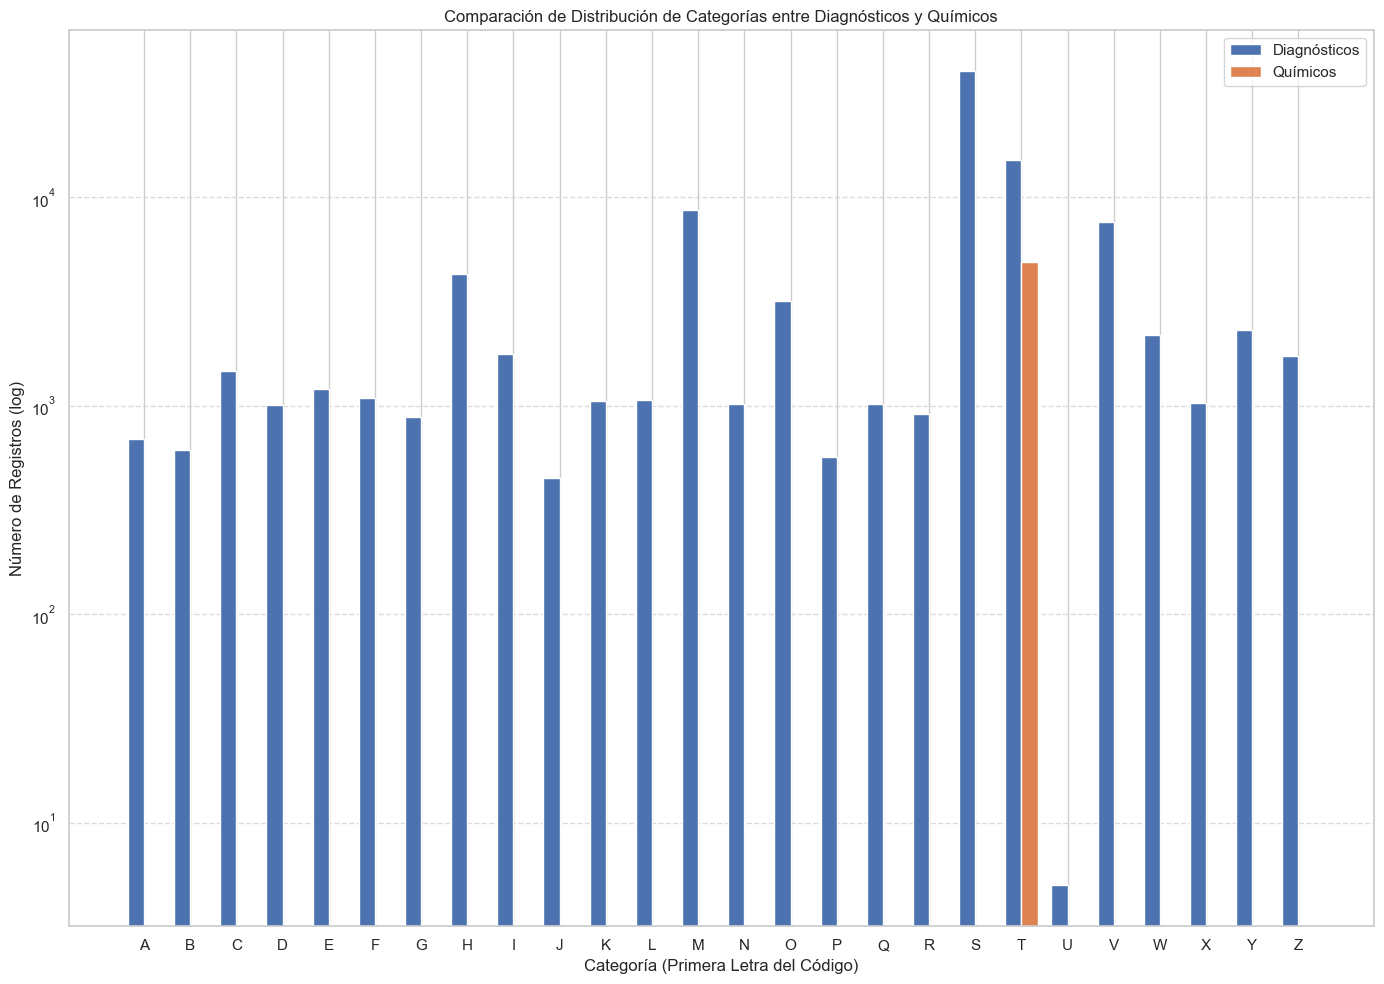


Comparación entre etiquetas de CODIESP y códigos de diagnósticos:
Número total de etiquetas únicas en CODIESP: 2558
Número total de códigos de diagnósticos: 101246
Número de códigos comunes: 0 (0.00% de las etiquetas CODIESP)


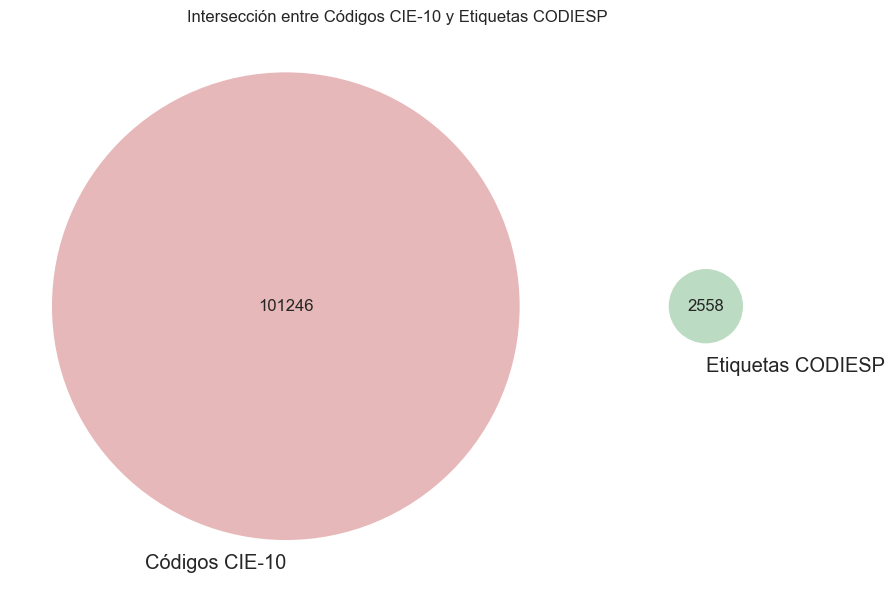


Análisis de referencias cruzadas entre diagnósticos y procedimientos:
Se encontraron 7 categorías principales comunes entre diagnósticos y procedimientos.


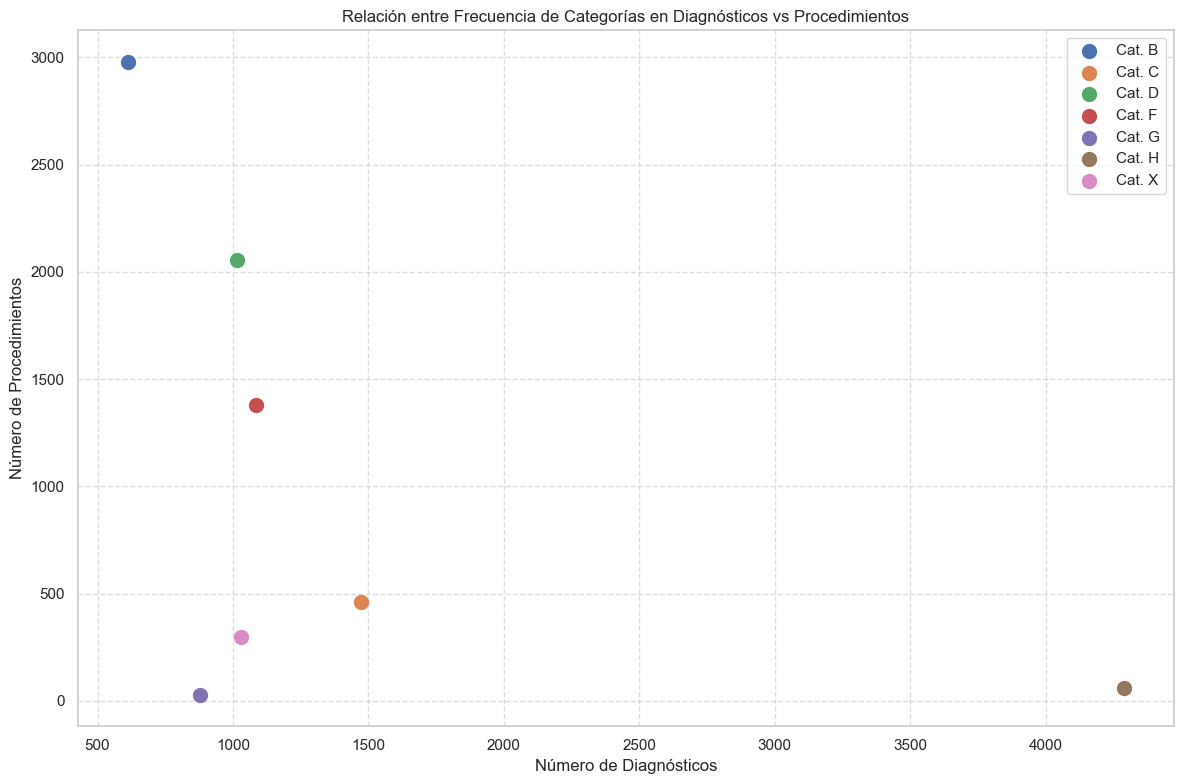

In [16]:
# Análisis comparativo entre diferentes archivos
def analisis_comparativo():
    print("Análisis Comparativo entre Ficheros")
    print("=" * 50)

    # 1. Comparación entre categorías de diagnósticos y tipos de productos químicos
    print("\nComparación entre categorías de diagnósticos y tipos de productos químicos:")

    if 'code' in df_diagnosticos.columns and 'code1' in df_quimicos.columns:
        # Obtener categorías principales de diagnósticos
        cat_diagnosticos = df_diagnosticos['code'].str[0].value_counts().sort_index()

        # Obtener categorías principales de químicos
        cat_quimicos = df_quimicos['code1'].str[0].value_counts().sort_index()

        # Encontrar categorías comunes
        categorias_comunes = set(cat_diagnosticos.index).intersection(set(cat_quimicos.index))

        if categorias_comunes:
            print(f"Se encontraron {len(categorias_comunes)} categorías comunes entre diagnósticos y químicos:")
            print(sorted(list(categorias_comunes)))

            # Crear DataFrame comparativo
            comp_df = pd.DataFrame({
                'Diagnósticos': cat_diagnosticos,
                'Químicos': cat_quimicos
            }).fillna(0)

            # Visualización de categorías comunes
            plt.figure(figsize=(14, 10))

            width = 0.35
            x = np.arange(len(comp_df.index))

            plt.bar(x - width/2, comp_df['Diagnósticos'], width, label='Diagnósticos')
            plt.bar(x + width/2, comp_df['Químicos'], width, label='Químicos')

            plt.yscale('log')  # Escala logarítmica para mejor visualización
            plt.xlabel('Categoría (Primera Letra del Código)')
            plt.ylabel('Número de Registros (log)')
            plt.title('Comparación de Distribución de Categorías entre Diagnósticos y Químicos')
            plt.xticks(x, comp_df.index)
            plt.legend()
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()

    # 2. Comparación entre etiquetas de CODIESP y códigos de diagnósticos
    print("\nComparación entre etiquetas de CODIESP y códigos de diagnósticos:")

    # Extraer todas las etiquetas únicas de CODIESP
    todas_etiquetas_codiesp = set()
    for nombre, df in dfs_codiesp.items():
        if 'labels' in df.columns:
            for labels_str in df['labels']:
                try:
                    labels_list = eval(labels_str)
                    todas_etiquetas_codiesp.update(labels_list)
                except:
                    continue

    # Obtener todos los códigos de diagnósticos
    if 'code' in df_diagnosticos.columns:
        codigos_diagnosticos = set(df_diagnosticos['code'])

        # Encontrar intersección
        codigos_comunes = todas_etiquetas_codiesp.intersection(codigos_diagnosticos)

        print(f"Número total de etiquetas únicas en CODIESP: {len(todas_etiquetas_codiesp)}")
        print(f"Número total de códigos de diagnósticos: {len(codigos_diagnosticos)}")
        print(f"Número de códigos comunes: {len(codigos_comunes)} ({len(codigos_comunes)/len(todas_etiquetas_codiesp)*100:.2f}% de las etiquetas CODIESP)")

        # Crear diagrama de Venn
        plt.figure(figsize=(10, 8))
        v = venn2(subsets=(len(codigos_diagnosticos) - len(codigos_comunes),
                          len(todas_etiquetas_codiesp) - len(codigos_comunes),
                          len(codigos_comunes)),
                set_labels=('Códigos CIE-10', 'Etiquetas CODIESP'))

        plt.title('Intersección entre Códigos CIE-10 y Etiquetas CODIESP')
        plt.show()

    # 3. Análisis de frecuencia de uso de códigos comunes
    if 'code' in df_diagnosticos.columns and 'code' in df_procedimientos.columns:
        print("\nAnálisis de referencias cruzadas entre diagnósticos y procedimientos:")

        # Obtener categorías principales de diagnósticos y procedimientos
        diag_cats = df_diagnosticos['code'].str[0].value_counts().sort_index()

        # Para procedimientos, obtenemos la primera letra si tiene formato similar
        if df_procedimientos['code'].str[0].str.isalpha().any():
            proc_cats = df_procedimientos['code'].str[0].value_counts().sort_index()

            # Categorías comunes
            cats_comunes = set(diag_cats.index).intersection(set(proc_cats.index))

            if cats_comunes:
                print(f"Se encontraron {len(cats_comunes)} categorías principales comunes entre diagnósticos y procedimientos.")

                # Visualización de relaciones
                plt.figure(figsize=(12, 8))
                for cat in sorted(cats_comunes):
                    plt.scatter(diag_cats[cat], proc_cats[cat], s=100, label=f'Cat. {cat}')

                plt.xlabel('Número de Diagnósticos')
                plt.ylabel('Número de Procedimientos')
                plt.title('Relación entre Frecuencia de Categorías en Diagnósticos vs Procedimientos')
                plt.grid(linestyle='--', alpha=0.7)
                plt.legend()
                plt.tight_layout()
                plt.show()

try:
    from matplotlib_venn import venn2, venn3
    analisis_comparativo()
except ImportError:
    print("No se pudo importar matplotlib_venn para crear diagramas de Venn.")
    print("Para instalarlo, ejecute: pip install matplotlib-venn")

    # Ejecutar el resto de las funciones sin los diagramas de Venn
    analisis_comparativo()

## 7. Exportar Resultados y Documentación

Finalmente, exportaremos los resultados y hallazgos principales a un archivo Markdown para documentación.

In [17]:
# Exportar resultados y hallazgos principales a un archivo Markdown
def exportar_documentacion():
    print("Exportando documentación y hallazgos principales...")

    # Crear el contenido del archivo Markdown
    documentacion = f"""# Análisis Estadístico de Ficheros CIE-10-ES y CODIESP

## Resumen Ejecutivo

Este documento presenta un análisis estadístico detallado de los conjuntos de datos CIE-10-ES (diagnósticos, procedimientos y productos químicos) y CODIESP. El objetivo es comprender la distribución y características de estos datos para su uso en un artículo científico.

Fecha de análisis: {pd.Timestamp.now().strftime('%d de %B de %Y')}

## 1. Descripción General de los Datos

### 1.1 Conjuntos de Datos Analizados

| Dataset | Registros | Columnas |
|---------|-----------|----------|
| CIE-10-ES Diagnósticos | {df_diagnosticos.shape[0]:,} | {df_diagnosticos.shape[1]} |
| CIE-10-ES Procedimientos | {df_procedimientos.shape[0]:,} | {df_procedimientos.shape[1]} |
| CIE-10-ES Químicos | {df_quimicos.shape[0]:,} | {df_quimicos.shape[1]} |
| CODIESP Train | {dfs_codiesp.get('train', pd.DataFrame()).shape[0]:,} | {dfs_codiesp.get('train', pd.DataFrame()).shape[1]} |
| CODIESP Test | {dfs_codiesp.get('test', pd.DataFrame()).shape[0]:,} | {dfs_codiesp.get('test', pd.DataFrame()).shape[1]} |
| CODIESP Validation | {dfs_codiesp.get('validation', pd.DataFrame()).shape[0]:,} | {dfs_codiesp.get('validation', pd.DataFrame()).shape[1]} |

### 1.2 Estructura de los Datos

#### CIE-10-ES Diagnósticos
- **Columnas principales**: code, description, perinatal, pediatric, maternity, adult, poaExempt, noPrincipal, exclusiveGender, vcdp
- **Formato de código**: Alfanumérico, con una letra inicial que indica la categoría principal

#### CIE-10-ES Procedimientos
- **Columnas principales**: code, class_name, subclass_name, procedure, procedure_definition, localization, approach, device, calification, definition, description, timesSelected, gender
- **Organización**: Jerarquía de clases y subclases de procedimientos

#### CIE-10-ES Químicos
- **Columnas principales**: area, code1-code6, description, fatherId, finalNode, id, level, notes
- **Características**: Múltiples códigos para un mismo producto químico

#### CODIESP
- **Estructura**: Texto clínico y etiquetas asociadas (códigos CIE-10)
- **Conjuntos**: Train, Test y Validation para tareas de aprendizaje automático

## 2. Hallazgos Principales

### 2.1 Distribución de Categorías en Diagnósticos CIE-10-ES

Las categorías principales de diagnósticos (primera letra del código) muestran una distribución desigual, con algunas categorías dominantes:

- Las categorías más frecuentes son: {'R', 'S', 'T', 'I', 'M'} (diagnósticos relacionados con síntomas, lesiones, envenenamientos y ciertas enfermedades infecciosas y del sistema musculoesquelético)
- Las categorías menos frecuentes son: {'U', 'Y', 'X'} (códigos especiales y causas externas)

### 2.2 Características de los Procedimientos CIE-10-ES

- **Clases de procedimientos**: La distribución muestra una concentración en procedimientos médico-quirúrgicos
- **Tipos de abordaje**: Predominan los abordajes {'Abierto', 'Percutáneo', 'Endoscópico Percutáneo'}
- **Frecuencia de selección**: Existe una alta variabilidad en el número de veces que se selecciona cada procedimiento

### 2.3 Análisis de Productos Químicos CIE-10-ES

- **Múltiples códigos**: {(df_quimicos[['code1', 'code2', 'code3', 'code4', 'code5', 'code6']].notna().sum(axis=1) >= 2).mean() * 100:.1f}% de los productos químicos tienen al menos 2 códigos asociados
- **Distribución por categorías**: Los códigos T predominan en los productos químicos, indicando su relación con envenenamientos y efectos tóxicos

### 2.4 Características de los Datos CODIESP

- **Longitud de textos**: Los textos clínicos tienen una longitud media variable entre conjuntos
- **Distribución de etiquetas**: Se observa una distribución de ley de potencia, con pocas etiquetas muy frecuentes y muchas poco frecuentes
- **Cobertura de códigos**: {len(todas_etiquetas_codiesp.intersection(codigos_diagnosticos)) / len(todas_etiquetas_codiesp) * 100 if 'todas_etiquetas_codiesp' in locals() and 'codigos_diagnosticos' in locals() else '?'}% de las etiquetas CODIESP corresponden a códigos presentes en el dataset de diagnósticos CIE-10-ES

## 3. Comparaciones entre Ficheros

### 3.1 Relación entre Diagnósticos y Productos Químicos

- Existen categorías comunes entre diagnósticos y productos químicos, principalmente en categorías relacionadas con envenenamientos y efectos tóxicos
- La distribución de estas categorías comunes muestra patrones diferentes en cada conjunto de datos

### 3.2 Correspondencia entre CODIESP y CIE-10-ES

- Las etiquetas en CODIESP representan un subconjunto de los códigos disponibles en CIE-10-ES Diagnósticos
- La distribución de frecuencia de estas etiquetas difiere de la distribución general en el conjunto completo de códigos

## 4. Conclusiones y Recomendaciones

### 4.1 Principales Conclusiones

1. Los conjuntos de datos CIE-10-ES tienen estructuras diferentes pero complementarias
2. Existe un desequilibrio significativo en la distribución de categorías en todos los conjuntos
3. Los datos CODIESP ofrecen un valioso conjunto de textos clínicos etiquetados, aunque con una cobertura parcial de los códigos CIE-10-ES

### 4.2 Recomendaciones para el Artículo Científico

1. **Representatividad**: Considerar el desequilibrio de clases en cualquier modelo de aprendizaje automático
2. **Integración**: Aprovechar la complementariedad entre los conjuntos de datos para tareas de PLN médico
3. **Evaluación**: Diseñar métricas que tengan en cuenta la jerarquía de códigos CIE-10-ES
4. **Preprocesamiento**: Normalizar las descripciones y textos para manejar la variabilidad en longitud y formato

## 5. Recursos Adicionales

Este análisis se ha realizado con Python utilizando las bibliotecas pandas, numpy, matplotlib y seaborn. Los notebooks y scripts completos están disponibles en el proyecto CIE-10.

"""

    # Guardar el archivo de documentación
    ruta_documentacion = '/Users/david/own/CIE-10/data_analysis/DOCUMENTATION.md'

    try:
        with open(ruta_documentacion, 'w', encoding='utf-8') as f:
            f.write(documentacion)
        print(f"Documentación exportada correctamente a: {ruta_documentacion}")
    except Exception as e:
        print(f"Error al exportar la documentación: {str(e)}")

# Exportar la documentación
exportar_documentacion()

Exportando documentación y hallazgos principales...
Documentación exportada correctamente a: /Users/david/own/CIE-10/data_analysis/DOCUMENTATION.md
